# **NGUYỄN THÁI NGÂN - K234131610 - Midterm**

# **Data description**

The ECSU dataset was selected for use in this paper because it clearly represents the nature of a real economic time series, collected periodically by month from 2006 to present. With a sufficiently large data length and continuity over time, this dataset meets the necessary requirements for applying and evaluating the effectiveness of time series forecasting models such as Holt, ARIMA, SARIMA, GARCH, etc. The choice of ECSU also comes from its high applicability, when the data series reflects the actual fluctuations in a specific economic phenomenon, thereby helping to test the forecasting ability, measure errors and compare the effectiveness between models. In addition, the data is well standardized, has few missing values ​​and has a clear time format, convenient for processing, analysis and presentation in the research paper. These are important factors contributing to ensuring the reliability and feasibility of the analysis results in the paper.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel('ECSU.xlsx')
df = df.sort_index()
df.dropna(inplace=True)
print(df.head())


        Date        ECSU
0 2006-01-01  131.713784
1 2006-02-01  132.222988
2 2006-03-01  268.604851
3 2006-04-01  246.869385
4 2006-05-01  263.061204


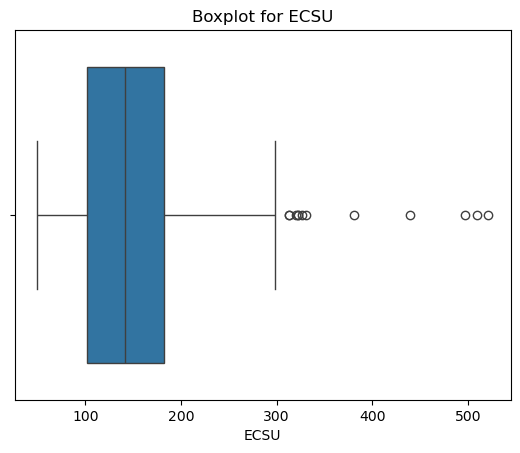

In [3]:
sns.boxplot(x=df['ECSU'])
plt.title('Boxplot for ECSU')
plt.show() 

In [5]:
Q1 = df['ECSU'].quantile(0.25)
Q3 = df['ECSU'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['ECSU'] < Q1 - 1.5 * IQR) | (df['ECSU'] > Q3 + 1.5 * IQR)]

print(outliers)

          Date        ECSU
34  2008-11-01  322.070216
35  2008-12-01  321.862268
56  2010-09-01  331.160312
63  2011-04-01  327.015073
69  2011-10-01  312.528676
71  2011-12-01  381.104604
86  2013-03-01  319.792272
91  2013-08-01  312.844203
170 2020-03-01  439.808857
192 2022-01-01  509.152931
193 2022-02-01  497.227542
195 2022-04-01  521.294616


=> From the box plot above and the outliers printed out, this dataset has 12 outliers. But we cannot remove them because the ECSU index reflects times of high economic uncertainty due to major events such as financial crises, political instability or pandemics. Removing them would destroy the essence of the index, which is designed to measure the level of uncertainty in the economy. Outliers in the ECSU index mainly appear at times of major economic and political shocks, both domestic and international. Specifically, the peaks in late 2008 reflect the impact of the global financial crisis; 2011 and 2013 are associated with domestic (e.g. the Gezi Park protests) and regional (Arab Spring) political instability; 2020 records the impact of the COVID-19 pandemic; while 2022 reflects record high inflation, the fall in the value of the lira, and the impact of the Russia–Ukraine war. These outliers accurately reflect the periods of high uncertainty that the ECSU index is intended to address. Therefore, maintaining these values ​​is necessary to ensure the integrity and economic meaning of the index.

In [8]:
!pip install fredapi
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

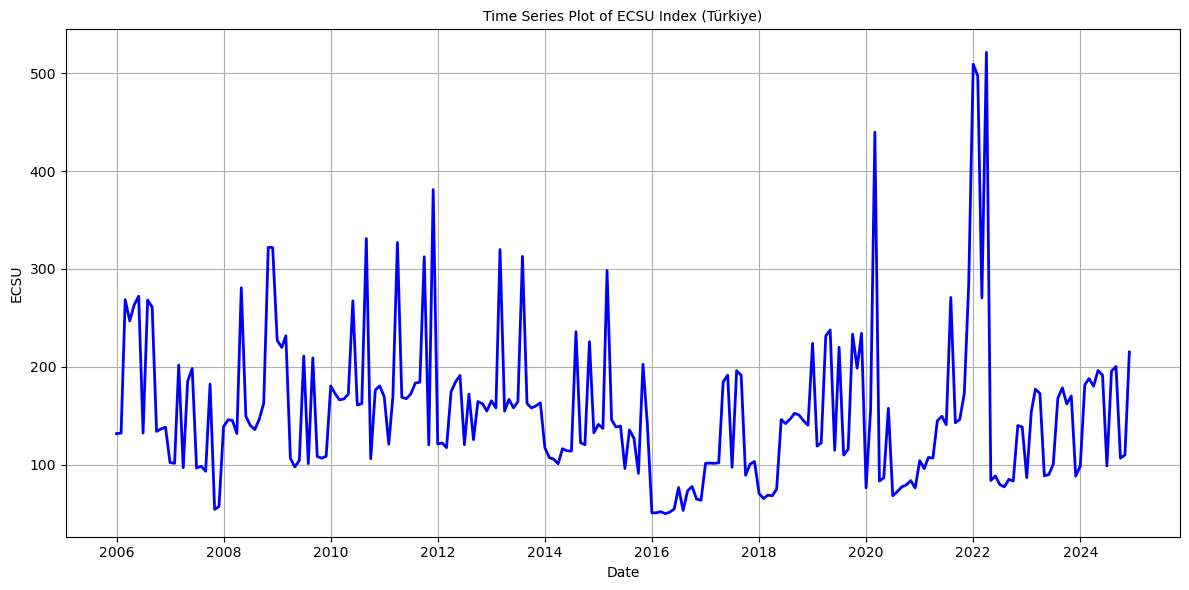

In [10]:
df = df.sort_values('Date')
# Vẽ biểu đồ chuỗi thời gian
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['ECSU'], color='blue', linewidth=2)
plt.title('Time Series Plot of ECSU Index (Türkiye)', fontsize=10)
plt.xlabel('Date')
plt.ylabel('ECSU')
plt.grid(True)
plt.tight_layout()
plt.show()

The time series plot of the Economic Country-Specific Uncertainty (ECSU) Index for Türkiye, covering the period from January 2006 to April 2024, reveals a highly volatile pattern, characterized by numerous sharp spikes that reflect sudden surges in economic uncertainty. During the 2008–2009 global financial crisis and subsequent domestic events such as the Gezi Park protests in 2013, the ECSU index recorded elevated values, indicating increased uncertainty in the national economic environment.

Between 2016 and 2019, the index stabilized at relatively lower levels, suggesting a period of relative calm. However, a significant escalation occurred starting in early 2020, coinciding with the onset of the COVID-19 pandemic, ongoing domestic economic difficulties, and geopolitical shocks such as the Russia–Ukraine war in 2022. This period featured the highest peaks in the series, with ECSU values surpassing 500.

In the most recent period (2023–2024), the index shows signs of decline, albeit with continued fluctuations, suggesting that while some sources of uncertainty have diminished, the broader economic environment remains fragile. Overall, the ECSU index illustrates the sensitivity of economic uncertainty to both global and domestic shocks, and its non-stationary nature implies that appropriate transformations (e.g., log returns) are necessary for effective modeling and forecasting.



In [13]:
print(df['ECSU'].describe())


count    228.000000
mean     155.207880
std       77.883960
min       49.903603
25%      101.533931
50%      141.654062
75%      181.741170
max      521.294616
Name: ECSU, dtype: float64


**Number of observations (count):** **228**
→ The dataset consists of 228 ECSU values ​​(monthly).

**Mean value (mean):** ≈ **155.21**
→ The average Swiss EPU index during the observation period is about 155.21 points.

**Standard deviation (std):** ≈ **77.88**
→ Shows a fairly large degree of volatility around the mean value, reflecting the uncertainty in economic policy with significant fluctuations between months.

**Minimum value (min):** ≈ **49.90**
→ The lowest in the series is about 49.90 points, indicating a period of fairly stable policy.

**25th percentile (25%):** ≈ **101.53**

**50th percentile (Median - 50%):** ≈ **141.65**

**75th percentile (75%):** ≈ **181.74**

→ These three markers show that the data distribution is slightly skewed to the right (tends to skew right), because the median is smaller than the mean (141.65 < 155.21).

**Maximum value (max):** ≈ **521.29**
→ This is a very high value, indicating that there was a time when economic and policy instability peaked, possibly due to a financial crisis, an epidemic or major political upheaval.



In [16]:
# Check missing values
print("Missing values by column:\n", df.isnull().sum())
df_clean = df.dropna()

Missing values by column:
 Date    0
ECSU    0
dtype: int64


=> From there, I can conclude this data have not missing value 

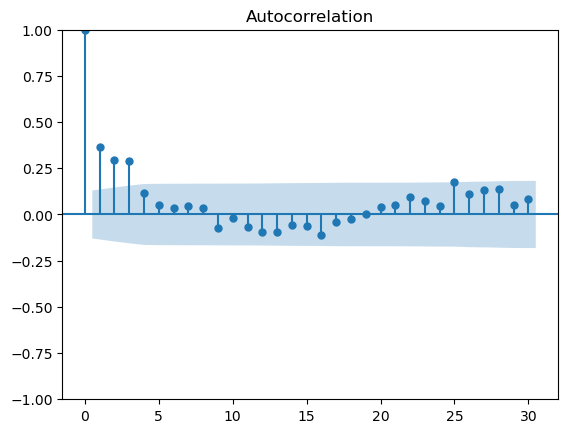

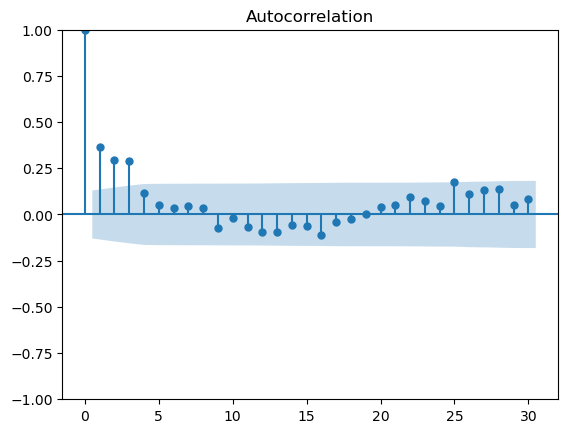

In [19]:
plot_acf(df['ECSU'],lags=30)

From this figure we can determine that this lags=3, from which we can see the coefficient of MA=1,2,3

The number of lags = 3 is reasonable because the first 3 lags all have statistically significant autocorrelations.

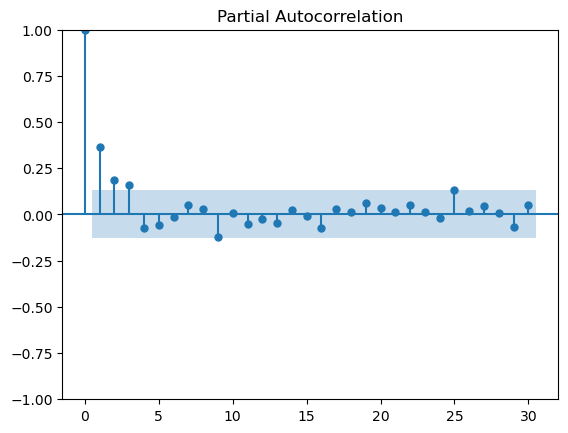

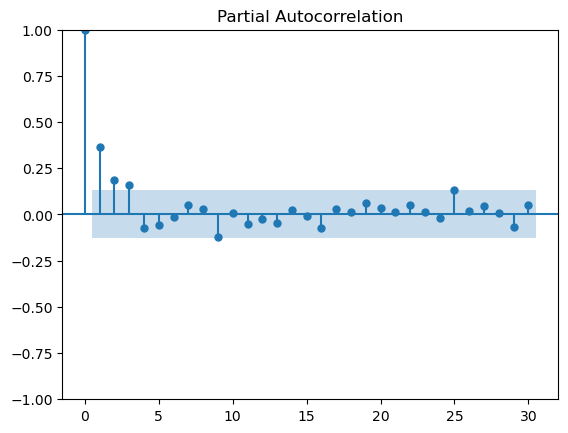

In [22]:
plot_pacf(df['ECSU'],lags=30)

From this figure we can determine that this lags=3, from which we can see the coefficient of MA=1,2,3

The number of lags = 3 is reasonable because the first 3 lags all have statistically significant autocorrelations.


In [25]:
# create log return variable
df['log_ECSU'] = np.log(df['ECSU']) - np.log(df['ECSU'].shift(1))
df.head()

,Date,ECSU,log_ECSU
0,2006-01-01,131.713784,NaN
1,2006-02-01,132.222988,0.003859
2,2006-03-01,268.604851,0.708752
3,2006-04-01,246.869385,-0.084382
4,2006-05-01,263.061204,0.063527


# **Time Series feature engineering**

In [28]:
!pip install ta
!pip install xgboost
!pip install pandas_datareader 

In [29]:
#Load Relevant Packages
import numpy as np
import pandas as pd
from pandas import DataFrame
import yfinance as yf
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn import preprocessing
from pandas_datareader import data as pdr
import warnings
import ta
from ta import add_all_ta_features
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
sns.set()

%matplotlib inline

In [32]:
plt.rcParams['figure.figsize'] = (12, 8)

In [34]:
start = '2006-1-1'
end = '2024-1-12'

In [36]:
df.tail()

,Date,ECSU,log_ECSU
223,2024-08-01,195.444471,0.684110
224,2024-09-01,200.335422,0.024717
225,2024-10-01,106.665681,-0.630294
226,2024-11-01,109.889743,0.029778
227,2024-12-01,215.145348,0.671836


In [38]:
# Đọc file
df = pd.read_excel("ECSU.xlsx")



# Tính log return
df['Log Return'] = np.log(df['ECSU']).diff()


In [40]:
df.head()

,Date,ECSU,Log Return
0,2006-01-01,131.713784,NaN
1,2006-02-01,132.222988,0.003859
2,2006-03-01,268.604851,0.708752
3,2006-04-01,246.869385,-0.084382
4,2006-05-01,263.061204,0.063527


In [42]:
import pandas as pd
import numpy as np

# Giả sử em đã đọc file và đặt EPU làm cột chính
# df = pd.read_excel("Korea_Overall_EPU (1).xlsx")
# df = df.rename(columns={"News-based EPU Index": "EPU"})
# df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# 1. Tạo đặc trưng liên quan đến ngày
df['f01'] = df.index.year
df['f02'] = df.index.month
df['f03'] = df.index.day
df['f04'] = df.index.dayofweek
df['f05'] = df.index.quarter

# 2. Lag Features (lùi thời gian)
df['f06'] = df['ECSU'].shift(1)   # Lag 1 tháng
df['f07'] = df['ECSU'].shift(2)
df['f08'] = df['ECSU'].shift(6)
df['f09'] = df['ECSU'].shift(12)

# 3. Rolling Mean (SMA) & Exponential Weighted Moving Average (EWMA)
df['f10'] = df['ECSU'].rolling(3).mean()
df['f11'] = df['ECSU'].rolling(6).mean()
df['f12'] = df['ECSU'].rolling(12).mean()
df['f13'] = df['ECSU'].rolling(24).mean()

df['f14'] = df['ECSU'].ewm(span=3).mean()
df['f15'] = df['ECSU'].ewm(span=6).mean()
df['f16'] = df['ECSU'].ewm(span=12).mean()
df['f17'] = df['ECSU'].ewm(span=24).mean()

# 4. Expanding Window
df['f18'] = df['ECSU'].expanding().mean()
df['f19'] = df['ECSU'].expanding().std()
df['f20'] = df['ECSU'].expanding().max()
df['f21'] = df['ECSU'].expanding().min()

# 5. EPU-specific indicators
df['f22'] = np.log(df['ECSU']).diff()                        # Log return
df['f23'] = df['f22'].rolling(12).std()                     # Rolling volatility
df['f24'] = df['ECSU'].rolling(12).apply(lambda x: np.polyfit(range(len(x)), x, 1)[0])  # Trend slope
df['f25'] = df['ECSU'] - df['ECSU'].expanding().mean()        # Deviation from mean

# 6. Xử lý thiếu dữ liệu
df = df.dropna().copy()


In [44]:
print(df[['ECSU', 'f06', 'f10', 'f22', 'f23']].tail())


                  ECSU         f06         f10       f22       f23
Date                                                              
2024-08-01  195.444471   98.609409  161.857059  0.684110  0.398748
2024-09-01  200.335422  195.444471  164.796434  0.024717  0.398468
2024-10-01  106.665681  200.335422  167.481858 -0.630294  0.439118
2024-11-01  109.889743  106.665681  138.963615  0.029778  0.438832
2024-12-01  215.145348  109.889743  143.900257  0.671836  0.435831


# **Time Series Decomposition**

In [47]:
# Packages
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [49]:

# Đọc file Excel, không dùng dayfirst ở bước này
DATA_FILE = 'ECSU.xlsx'
data = pd.read_excel(DATA_FILE)

# Đảm bảo cột 'Date' đúng tên và chuyển về định dạng datetime
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

# Đặt 'Date' làm chỉ mục
data.set_index('Date', inplace=True)

# Hiển thị 5 dòng cuối
print(data.tail())

                  ECSU
Date                  
2024-08-01  195.444471
2024-09-01  200.335422
2024-10-01  106.665681
2024-11-01  109.889743
2024-12-01  215.145348


In [51]:
y = data['ECSU'].copy() # Month period series
y.index = y.index.to_period(freq='M')

ts = data['ECSU'] # Day indexed series

I processed the time series data related to the ECSU variable by creating two different versions of the series: one with a monthly time index stored in the y variable, and the original series with a daily time index stored in the ts variable. The transformation makes the y variable suitable for monthly cyclical analysis models such as decomposition models. Meanwhile, ts still retains its daily structure to serve models that require high precision on a daily basis, typically the GARCH model used to analyze volatility.

In [54]:
data.describe().round(2)

,ECSU
count,228.00
mean,155.21
std,77.88
min,49.90
25%,101.53
50%,141.65
75%,181.74
max,521.29


In addition, this function provides basic descriptive statistics about the ECSU variable in the data set. Specifically, there are 228 observations, the mean value is 155.21, the standard deviation is 77.88, with a minimum value of 49.90 and a maximum of 521.29. The 25%, 50% (median) and 75% percentiles are 101.53, 141.65 and 181.74 respectively, indicating that the data distribution may be slightly right-skewed. This information is important to make a preliminary assessment of the dispersion and determine whether normalization, log transformation, or the use of a volatility model such as ARCH/GARCH is needed.

In [57]:
decomposition = sm.tsa.x13_arima_analysis(ts,x12path='.')

In [59]:
[attr for attr in dir(decomposition) if not attr.startswith('_')]

['irregular', 'observed', 'plot', 'results', 'seasadj', 'stdout', 'trend']

In [61]:
decomposition.seasadj.tail()

Date
2024-08-01    193.601069
2024-09-01    198.448564
2024-10-01    125.402365
2024-11-01    114.363472
2024-12-01    197.410646
Name: seasadj, dtype: float64

In time series analysis, the above three lines of code demonstrate the process of seasonally adjusting the data series using the X-13 ARIMA-SEATS method. First, the model is applied to decompose the original series into separate components such as trend, seasonal factor, and noise. Then, the system checks and displays the main components that can be exploited from this decomposition result. Finally, the seasonally adjusted data series (i.e., removing the seasonal effect) is extracted and the most recent values ​​are displayed. Removing the seasonal factor helps to clarify the true trend of the data, supporting more effective analysis and forecasting.

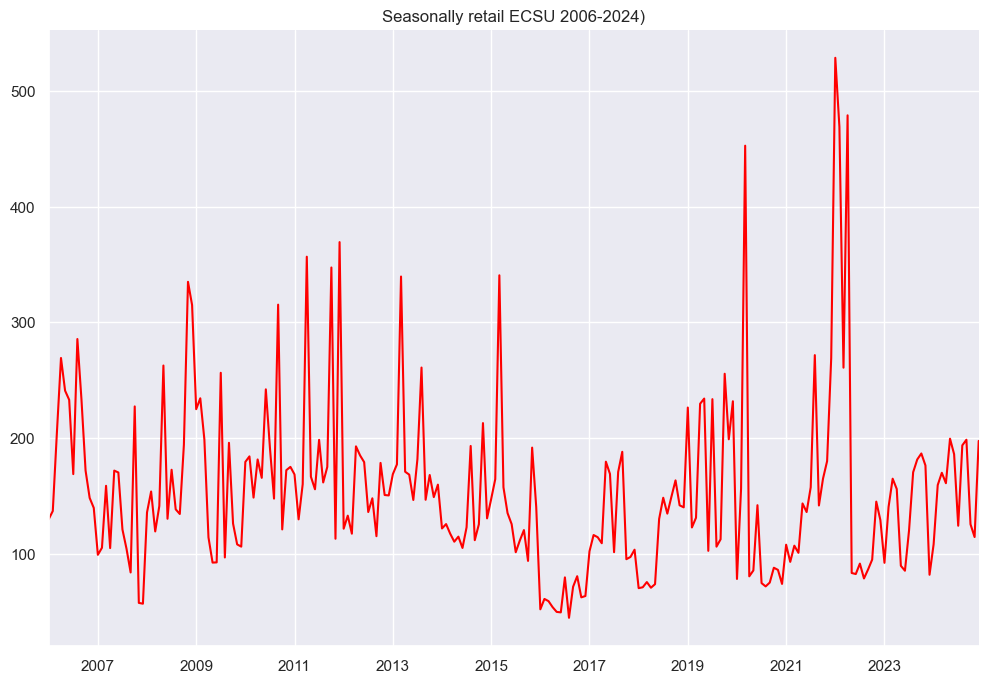

In [64]:
fig, ax= plt.subplots();#figsize=(9,6))
decomposition.seasadj.plot(color='red')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Seasonally retail ECSU 2006-2024)')
ax.set_xticks([], minor=True) # I prefer to remove the minor ticks for a cleaner plot
sns.despine()
plt.show() # Biểu đồ sau khi tách ra mùa vụ

The line graph shows the seasonal adjusted ECSU index over time from January 2006 to December 2024. The horizontal axis represents time in years, while the vertical axis represents the value of the ECSU index. The red line shows the trend of the data series over each month.

Looking at the chart, it can be seen that during the period 2006–2010, the ECSU value fluctuated strongly, with some peaks exceeding 300. From around 2011 to 2017, the series tended to decrease slightly and was relatively stable, with values ​​fluctuating between 100 and below 250. However, since 2018, especially in the period 2020–2022, the chart has seen many major spikes, with the ECSU index exceeding 500 at times – this could be a consequence of external shocks such as the COVID-19 pandemic or major policy changes.

After this spike, from 2022 to 2024, the series showed signs of a sharp decrease and returned to fluctuating around 100–200, showing relative stability compared to previous peak years. Overall, the chart clearly reflects the characteristics of the ECSU series, which is characterized by uneven volatility over time and the existence of extreme periods. This is an important basis for further analyzing the presence of heteroskedasticity and applying models such as ARCH/GARCH to forecast future risk or volatility.

In [67]:
f=open('x13results.txt', mode='w+')
f.write(decomposition.results)
f.close()

In [69]:
basic_decomposition = sm.tsa.seasonal_decompose(ts, model='multiplicative')

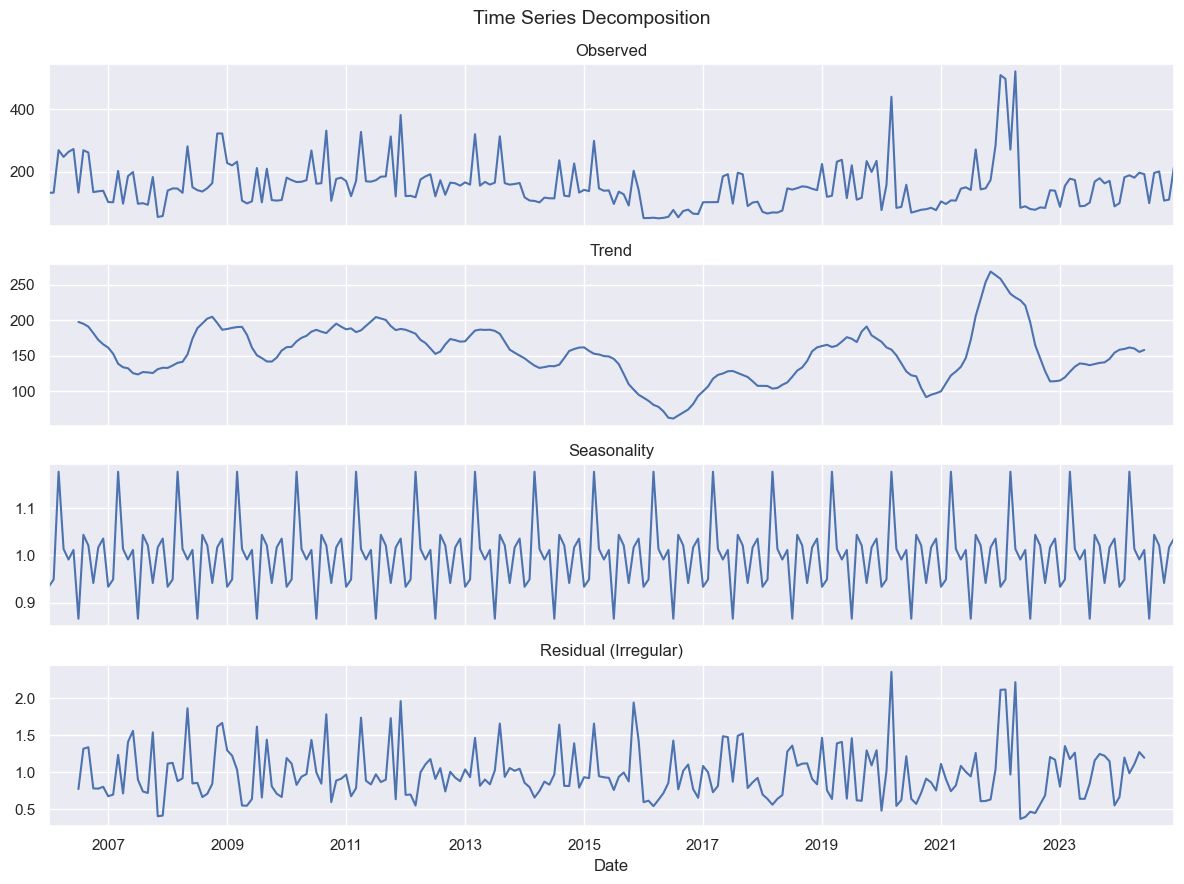

In [71]:
from plotting import plot_components_basic
plot_components_basic(basic_decomposition);

The time series decomposition diagram above illustrates the decomposition of the ECSU data series (2006–2024) into four basic components: **Observed, Trend, Seasonality, and Residual**, using a multiplicative decomposition model.

In the **Observed** part, it can be seen that the ECSU index fluctuates strongly, with many sharp peaks appearing suddenly, especially after the 2020 period, indicating instability and the possibility of seasonal factors or shocks. The **Trend** chart highlights the long-term trend of the series: the period from 2006 to around 2014 tends to decrease slightly or sideways, then gradually increases to a peak near 2021, and then decreases again in the recent period. The **Seasonality** component clearly shows strong and regular seasonality, with peaks and troughs repeating in an annual cycle. This regular wave line shows that ECSU is strongly influenced by seasonal factors, such as festivals, shopping times, or production cycles. Finally, the **Residual** reflects random or unusual fluctuations that are not explained by trends or seasons. In particular, after 2020, the residuals show large shocks, reflecting sudden instability that can originate from exogenous factors such as pandemics, policy fluctuations, or major changes in consumer behavior.


Additive Decomposition:
  AIC ≈ 1797.88

Multiplicative Decomposition:
  AIC ≈ 1798.64


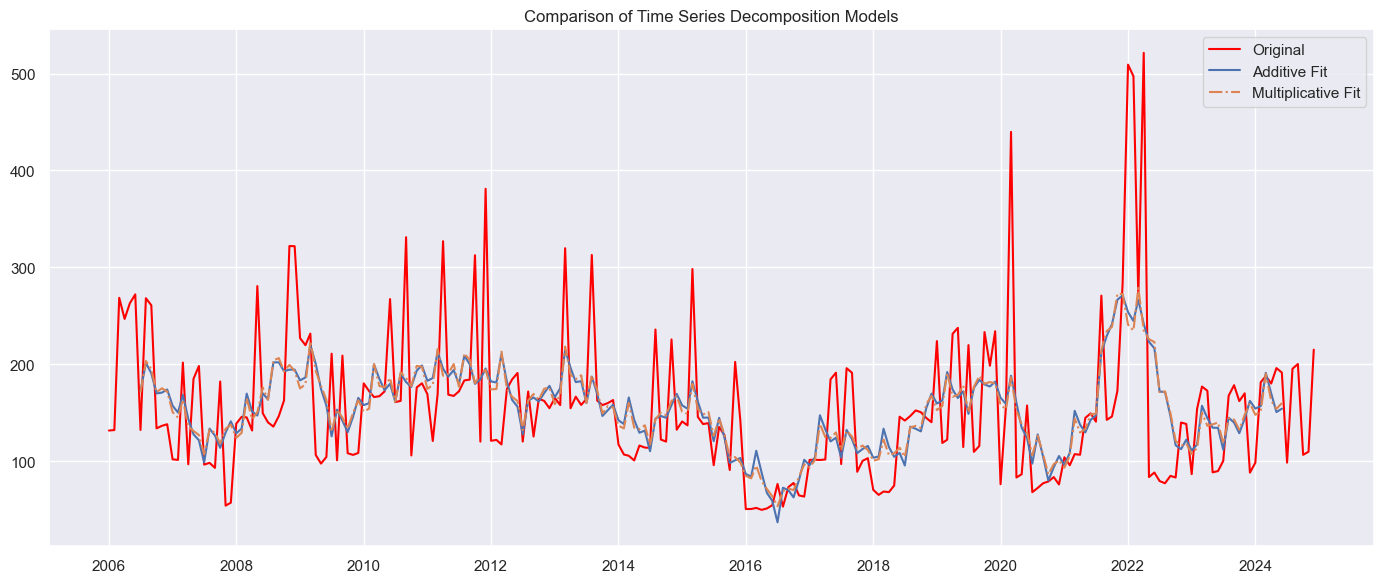

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

# Đọc dữ liệu
df = pd.read_excel("ECSU.xlsx")

# Đảm bảo định dạng thời gian
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df = df.asfreq('MS')  # Chuỗi theo tháng

# Chuỗi cần phân tích
series = df['ECSU'].dropna()

# Hàm tính AIC (xấp xỉ)
def compute_aic(original, fitted, k=2, model_name=""):
    valid = (~original.isna()) & (~fitted.isna())
    y_true = original[valid]
    y_pred = fitted[valid]
    rss = np.sum((y_true - y_pred)**2)
    n = len(y_true)
    aic = n * np.log(rss / n) + 2 * k
    print(f"\n{model_name} Decomposition:")
    print(f"  AIC ≈ {aic:.2f}")
    return aic

# 1. Additive Decomposition
result_add = seasonal_decompose(series, model='additive', period=12)
fitted_add = result_add.trend + result_add.seasonal
compute_aic(series, fitted_add, k=2, model_name="Additive")

# 2. Multiplicative Decomposition
result_mul = seasonal_decompose(series, model='multiplicative', period=12)
fitted_mul = result_mul.trend * result_mul.seasonal
compute_aic(series, fitted_mul, k=2, model_name="Multiplicative")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 6))
plt.plot(series, label='Original', color='red')
plt.plot(fitted_add, label='Additive Fit', linestyle='-')
plt.plot(fitted_mul, label='Multiplicative Fit', linestyle='-.')
plt.title("Comparison of Time Series Decomposition Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The above graph shows the comparison between the original data and two time series decomposition models, Additive and Multiplicative. Observed from 2006 to 2024, the ECSU data series shows clear fluctuations in each period. During the period from 2006 to around 2013, the series fluctuated strongly with unstable peaks and troughs, ranging from around 100 to over 300. From 2014 to 2019, the series tended to be more stable, fluctuating in a narrow range of around 100–200. However, from 2020 onwards, the series experienced many large shocks, especially in 2021–2022 with a spike exceeding 500, then decreasing and returning to a more stable level but still containing small fluctuations. In terms of modeling, both the Additive and Multiplicative models show the ability to follow the general trend of the series, especially in stable periods. However, when unusual peaks appear, especially shocks during the pandemic, both models do not show good response. The results of comparing the AIC index show that the Additive model has an AIC ≈ 1797.88, slightly lower than the AIC of the Multiplicative model of ≈ 1798.64, indicating that the Additive model is slightly more suitable for this data series.

In summary, the Additive decomposition model is a better choice than the Multiplicative in this case. However, because the series has many periods of strong fluctuations and non-linear characteristics, if the goal is accurate forecasting, more advanced models such as ARIMA, SARIMA, Prophet or deep learning models such as LSTM should be considered.

# STL forecast

In [78]:
df = pd.read_excel('ECSU.xlsx')
df

,Date,ECSU
0,2006-01-01,131.713784
1,2006-02-01,132.222988
2,2006-03-01,268.604851
3,2006-04-01,246.869385
4,2006-05-01,263.061204
...,...,...
223,2024-08-01,195.444471
224,2024-09-01,200.335422
225,2024-10-01,106.665681
226,2024-11-01,109.889743


C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\243015271.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = df_grouped.resample('M').sum()[:-1]


<Axes: xlabel='Date'>

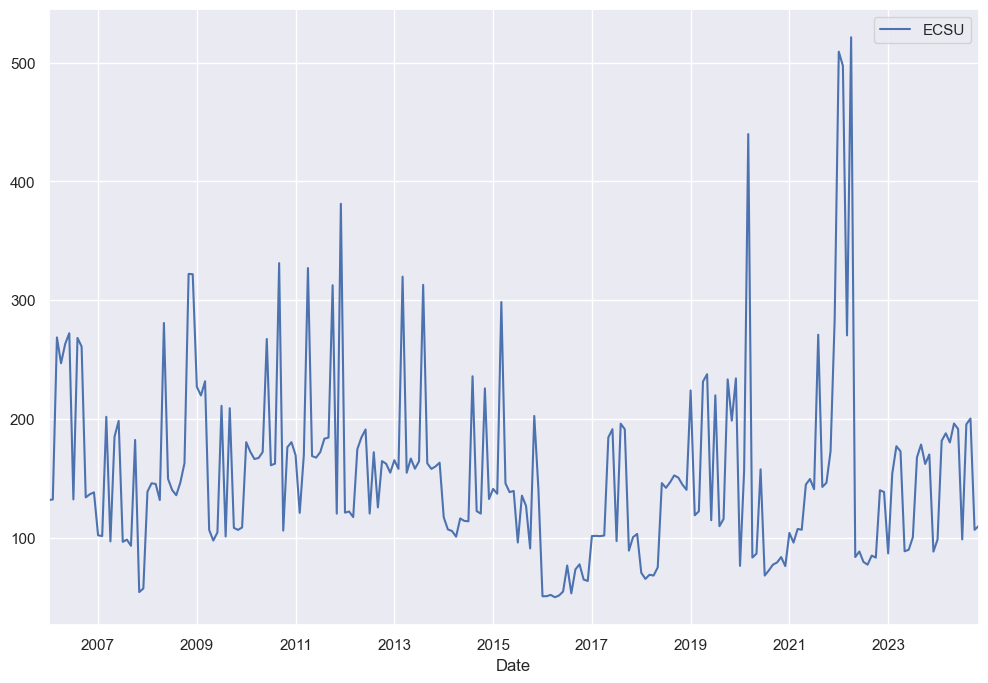

In [80]:
# Clean and visualize data
df_grouped = df[['Date', 'ECSU']].groupby('Date').sum()
df_grouped.index = pd.to_datetime(df_grouped.index, format="%Y-%m-%d")
data = df_grouped.resample('M').sum()[:-1]
data.plot()

The time series chart shows the evolution of the ECSU (Economic Policy Uncertainty – Switzerland) number from 2006 to 2024. The horizontal pad represents time in months, while the ECSU number may be glitched. Observing the chart shows that this index has modern variations over time, reflecting the level of uncertainty in Switzerland's economic policy.

Specifically, in the period from 2006 to around 2014, the index fluctuated relatively strongly with many peaks, typically in 2009 - the time of the global financial crisis. Then, from 2015 to 2017, the index tended to decrease and stabilize, with the level mainly below 150. However, from 2019 onwards, ECSU began to increase again and many unexpected fluctuations appeared, especially in the period 2020–2021 when the index reached above 500 – most likely due to the powerful impact of the COVID-19 pandemic and global instability. In the last two years (2022–2023), although the index tended to decrease slightly, it still maintained a higher fluctuation ability than in the first period.

The irregular, cyclical fluctuations and the appearance of strong fluctuation periods focus on the phenomenon of "volatility clusters" found – a particularly common phenomenon in finance and chain economics. This shows that the use of models such as ARCH or GARCH to analyze and forecast the fluctuations of ECSU is completely appropriate and necessary.

In [83]:
# Split into training and testing sets
train_data = data.ECSU[:-12]
test_data = data.ECSU[-12:]

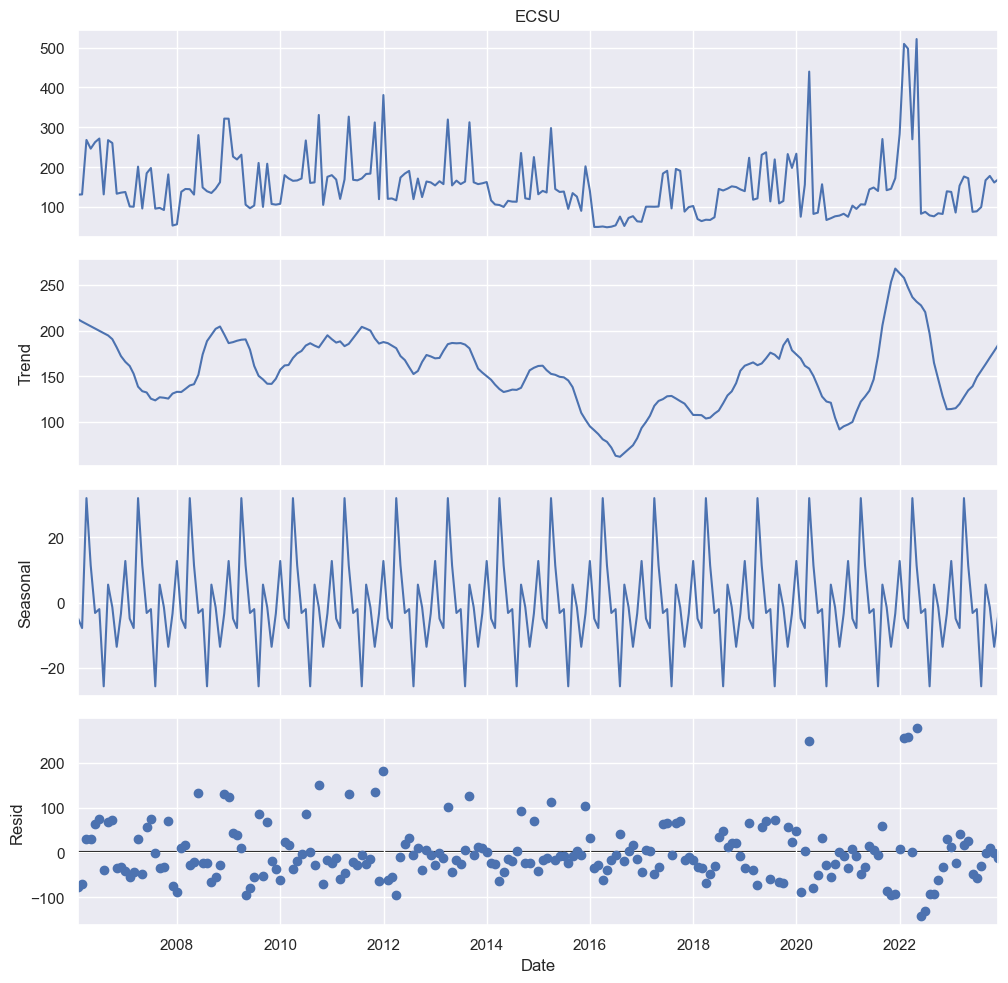

In [85]:
# Import library
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Decompose data by selecting the appropiate frequency
decomp = sm.tsa.seasonal_decompose(
  train_data, period=12,extrapolate_trend=True)
decomp_plot = decomp.plot()

# Plot outcome
plt.xlabel('Date')
decomp_plot.set_figheight(10)
decomp_plot.set_figwidth(10)
plt.show()

In [86]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

# Decompose the time series with STL
stl = STL(train_data, seasonal=13)
result = stl.fit()

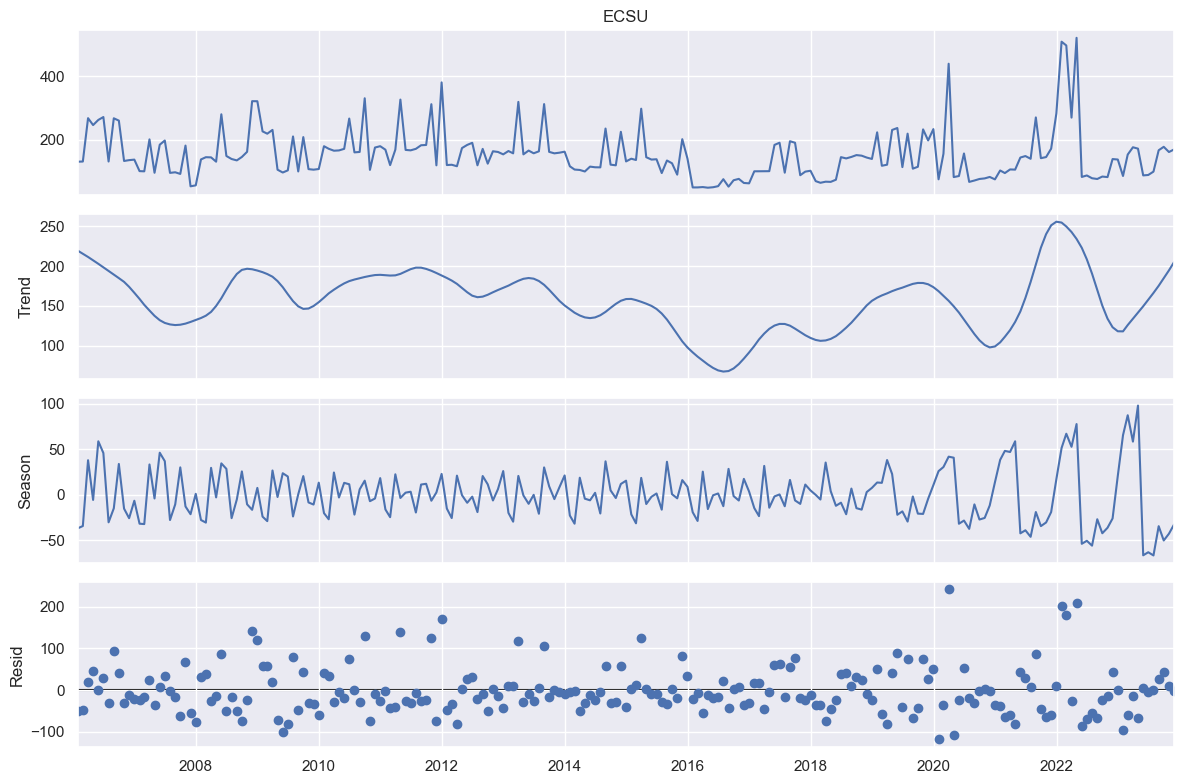

In [87]:
# Display decomposition
result.plot()
plt.show()

1. **Original series (Observed)**: The first chart shows the original time series of the ECSU index. Here we can clearly see the spikes around 2020–2021, reflecting major economic events (such as the COVID-19 pandemic).

2. **Trend component (Trend)**: The second chart shows the overall trend of the ECSU series. From 2006 to 2016, the trend was somewhat stable and slightly decreasing. However, from 2017 onwards, the trend increased significantly, especially after 2020 – indicating that the level of uncertainty in economic policy has tended to increase over the long term in recent years.

3. **Seasonal component (Seasonal)**: The third chart shows the seasonal effect. We can see the cyclical repetition, although the amplitude of the fluctuations is not large. This shows that the ECSU index has a seasonal element but it is not too obvious compared to the trend and sudden fluctuations.

4. **Residual**: The last chart is the residual after removing the trend and seasonality from the original series. The residual data mostly fluctuates around 0, but there are still many sudden noise points, especially in recent years - showing that there are still many unusual factors that the model has not fully explained.

**Conclusion**: STL analysis helps to clearly separate the structure of the ECSU series, showing the presence of a long-term upward trend and relatively stable seasonal factors.

In [92]:
# Function to forecast the seasonal component based on the extracted seasonality
def forecast_seasonal_component(result, steps, seasonal_period):
    # Repeat the seasonal component
    seasonal_component = np.tile(result.seasonal[-12:], steps // 12)

    # If steps is not a multiple of 12, add the remaining months
    if steps % 12:
        seasonal_component = np.concatenate([seasonal_component, result.seasonal[-12:-12+steps%12]])

    return seasonal_component 

In [94]:
# Deseasonalize the time series
deseasonalized = train_data - result.seasonal

In [96]:
# Forecast deseasonalized data

# Install the pmdarima if you don't have it - uncomment line
!pip install pmdarima==2.0.3

# Import the library
from pmdarima.arima import auto_arima

# Build and fit the AutoARIMA model
model = auto_arima(deseasonalized, seasonal=False, suppress_warnings=True)
model.fit(deseasonalized)

# Check the model summary
model.summary()

  Using cached pmdarima-2.0.3.tar.gz (630 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for pmdarima
Failed to build pmdarima


  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [14 lines of output]
  C:\Users\Ntngan2601\AppData\Local\Temp\pip-install-abvonm_6\pmdarima_31cd6bf2340e4f358ad441f6c70323aa\setup.py:15: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
    from pkg_resources import parse_version
  Partial import of pmdarima during the build process.
  
  Requirements: ['joblib>=0.11\nCython>=0.29,!=0.29.18,!=0.29.31\nnumpy>=1.21.2\npandas>=0.19\nscikit-learn>=0.22\nscipy>=1.3.2\nstatsmodels>=0.13.2\nurllib3\nsetuptools>=38.6.0,!=50.0.0\n']
  Adding extra setuptools args
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 34, in <module>
    File "C:\Users\Ntngan2601\AppData\Local\Temp\pip-install-abvonm_6\pmdarima_31cd6bf2340e4f358ad441f6c70323aa\setup.py", line 340, in <module>
      do_setup()
    F

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  215
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -1205.771
Date:                Wed, 02 Jul 2025   AIC                           2419.542
Time:                        14:05:32   BIC                           2433.025
Sample:                    01-31-2006   HQIC                          2424.990
                         - 11-30-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     29.5062     11.583      2.547      0.011       6.805      52.208
ar.L1          0.8119      0.071     11.509      0.000       0.674       0.950
ma.L1         -0.5157      0.102     -5.063      0.000      -0.715      -0.316
sigma2      4346.8266    354.443     12.264      0.000    3652.132    5041.521
===================================================================================
Ljung-Box (L1) (Q):                   0.29   Jarque-Bera (JB):                77.93
Prob(Q):                              0.59   Prob(JB):                         0.00
Heteroskedasticity (H):               1.45   Skew:                             1.04
Prob(H) (two-sided):                  0.11   Kurtosis:                         5.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**1. Model: SARIMAX(1, 0, 1)**
* First-order autoregressive component (AR(1)): the current value depends on the most recent past value.

* No need to take differences (I(0)): the series is considered stationary.
* First-order moving average component (MA(1)): the current error depends on the error of the previous period.

**2. Number of observations (No. Observations): 215**
Indicates that the number of data points used to estimate the model is 215.

**3. Log Likelihood = -1205.771**
This is the log-likelihood value of the model. The larger this value (i.e. less negative), the better the model fits the data.

**4. AIC = 2419.54, BIC = 2433.03, HQIC = 2424.99**
AIC (Akaike Information Criterion): 2419.54

BIC (Bayesian Information Criterion): 2433.03

HQIC (Hannan-Quinn): 2424.99
=> The smaller the AIC/BIC indexes, the better when comparing between different models.

**5. intercept = 29.5062, p-value = 0.011**
The intercept is statistically significant because the p-value is less than 0.05. It represents the fixed average value of the series when there is no impact from AR or MA components.

**6. ar.L1 = 0.8119, p-value = 0.000**
The AR(1) parameter is highly statistically significant. It shows that the value of the series depends strongly on itself in the previous period. The coefficient of 0.81 is quite high, reflecting a clear self-dependence.

**7. ma.L1 = -0.5157, p-value = 0.000**
The MA(1) parameter is also statistically significant. It shows the influence of noise (error) from the previous period on the current value. The negative coefficient (-0.5157) shows an inverse relationship with the previous period error.

**8. sigma2 = 4346.8266, p-value = 0.000**
This is the variance of the error. The smaller this value is, the more accurate the model is at predicting. High variance is a sign that the data has large fluctuations that are not fully explained.

**9. Ljung-Box Q-statistic (Q) = 0.29, p-value = 0.59**
This value is used to test whether the residuals are still autocorrelated. With p-value > 0.05, we do not reject the hypothesis that the residuals are random. Conclusion: the model has handled autocorrelation well.

**10. Jarque-Bera test (JB) = 77.93, p-value = 0.59**
Testing the normal distribution of the residuals. A high p-value shows that the residuals can be considered to follow a normal distribution.

**11. Heteroskedasticity (H) = 1.45**
Heteroskedasticity test coefficient. H close to 1 means that the residuals have stable variance – there is no serious heteroskedasticity phenomenon.

**12. Skew = 1.04**
The skewness coefficient indicates that the residuals are slightly skewed to the right. However, this level is acceptable.

**13. Kurtosis = 5.10**
The kurtosis coefficient indicates that the residuals have a "thicker tail" distribution than the normal distribution (kurtosis > 3). This may be a sign of outliers or unusual fluctuations.

**14. Prob(H) = 0.11**
The P-value of the heteroscedasticity test. With a value of 0.11 (> 0.05), we do not have enough evidence to reject the null hypothesis of constant variance. This reinforces the conclusion that the model is stable in terms of variance.

**Overall conclusion:**
The SARIMAX(1,0,1) model fits the deseasonalized data series well. The parameters are all statistically significant, the residuals are no longer autocorrelated and can be considered normally distributed. Therefore, this model can be used to forecast the non-seasonal part of the ECSU time series.

In [98]:
print(f"AIC của mô hình: {model.aic():.2f}")


AIC của mô hình: 2419.54


# **ARIMA for residual from STL**

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.51 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2355.822, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2357.814, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2357.813, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2357.808, Time=0.02 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.844 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  215
Model:                        SARIMAX   Log Likelihood               -1176.911
Date:                Wed, 02 Jul 2025   AIC                           2355.822
Time:                        14:09:40   BIC                           2359.192
Sample:                    01-31-2006   HQIC                          2357.184
                    

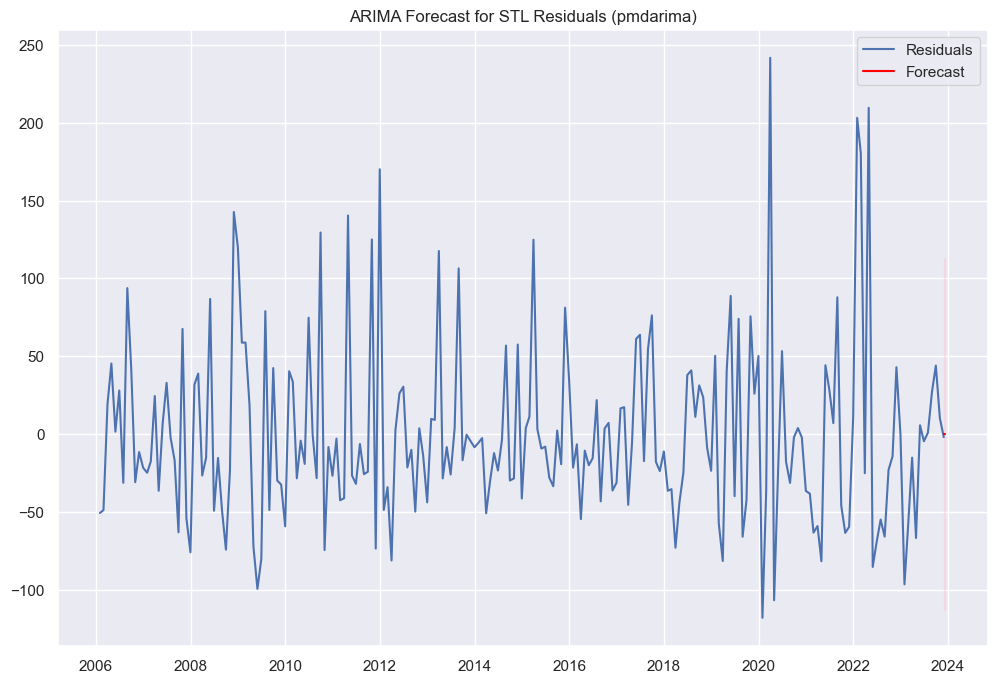

AIC: 2355.82


In [114]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
from pmdarima.arima import auto_arima
import matplotlib.pyplot as plt

# 1. Tách residuals từ STL
stl = STL(train_data, seasonal=13)
result = stl.fit()
residuals = result.resid

# 2. Chạy ARIMA tự động và dự báo
model = auto_arima(residuals, seasonal=False, trace=True)
print(model.summary())

# Dự báo với pmdarima (sử dụng predict() thay vì get_forecast())
forecast_mean, conf_int = model.predict(
    n_periods=12,  # Số bước dự báo
    return_conf_int=True  # Trả về khoảng tin cậy
)

# 3. Tạo index cho dự báo (phù hợp với test_data)
forecast_index = pd.date_range(
    start=residuals.index[-1] + pd.Timedelta(days=1), 
    periods=12, 
    freq='D'  # Tần suất ngày, điều chỉnh nếu cần
)

# 4. Vẽ biểu đồ
plt.plot(residuals.index, residuals, label='Residuals')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(
    forecast_index,
    conf_int[:, 0],  # Giới hạn dưới
    conf_int[:, 1],  # Giới hạn trên
    color='pink',
    alpha=0.3
)
plt.title('ARIMA Forecast for STL Residuals (pmdarima)')
plt.legend()
plt.grid(True)
plt.show()

print(f"AIC: {model.aic():.2f}")

In conclusion, the application of the STL decomposition method combined with the ARIMA model on the residuals has brought about a clear effect, as shown by the AIC value decreasing from 2419.54 to 2355.82. This improvement shows that the hybrid STL-ARIMA model is significantly better than using only ARIMA. The main reason for this improvement lies in the fact that STL has successfully separated the trend and seasonality components, allowing ARIMA to focus only on modeling the random residuals. This approach not only reduces the complexity of the model but also improves the ability to capture important features in the data. The lower AIC result shows that the hybrid model has optimized the balance between complexity and data explanatory ability, and shows that the residuals after decomposition have achieved the necessary stationarity. This method is especially effective for time series with obvious seasonal factors.

# **Holt's Linear Trend Model**

In [116]:
z=decomposition.seasadj.copy()
z.index=ts.index.to_period(freq='M')

In [118]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Fit mô hình Holt
model_sm = sm.tsa.Holt(z).fit()
smoothed_sm = model_sm.fittedvalues

# Hiển thị summary mô hình
model_sm.summary()


Dep. Variable:,seasadj,No. Observations:,228
Model:,Holt,SSE,1213304.113
Optimized:,True,AIC,1964.129
Trend:,Additive,BIC,1977.846
Seasonal:,None,AICC,1964.509
Seasonal Periods:,None,Date:,"Wed, 02 Jul 2025"
Box-Cox:,False,Time:,14:09:59
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3821429,alpha,True
smoothing_trend,0.0146978,beta,True


- From here we can see that the result of this AIC is quite low, only 1964.129

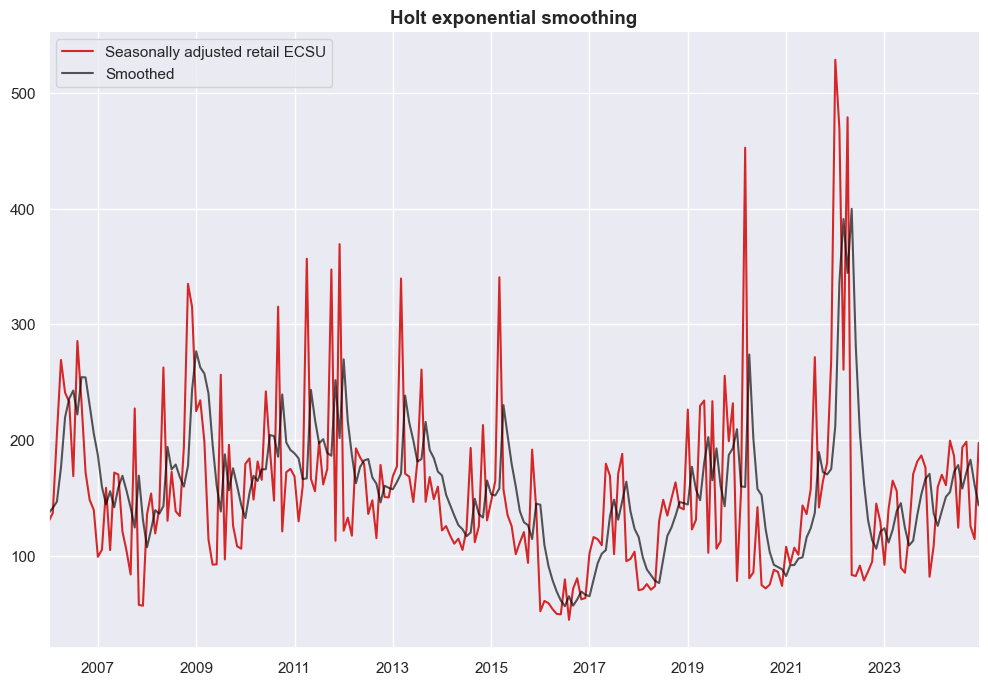

In [121]:
fig, ax= plt.subplots();#figsize=(9,6))

z['2006':].plot(color='#D62728', label='Seasonally adjusted retail ECSU')
smoothed_sm['2006':].plot(color='black', label='Smoothed', alpha=0.65)
plt.legend(loc='best')
ax.set_xlabel('')
ax.set_xticks([], minor=True)
ax.set_title(r'Holt exponential smoothing', fontsize=13.5, fontweight='bold')
sns.despine()
plt.show()

The graph illustrates the results of applying the Holt Exponential Smoothing method to analyze the seasonally adjusted retail sales (Retail ECSU) trend from 2006 to 2024. Through the graph, three main periods can be clearly seen: the 2007-2009 period with a sharp downward trend due to the impact of the financial crisis, the 2010-2019 period showing a stable recovery and growth, and the 2020-2023 period with strong fluctuations due to the impact of the COVID-19 pandemic. The smoothed line follows the overall trend but has a lag in responding to sudden fluctuations.

This method is effective in identifying long-term trends and eliminating noise, but is limited in handling irregular fluctuations and seasonal factors.

C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\1080709082.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[164.47210566]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_expanding.update(expanding.forecast(1))
C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\1080709082.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[170.44854212]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_rolling.update(rolling.forecast(1))


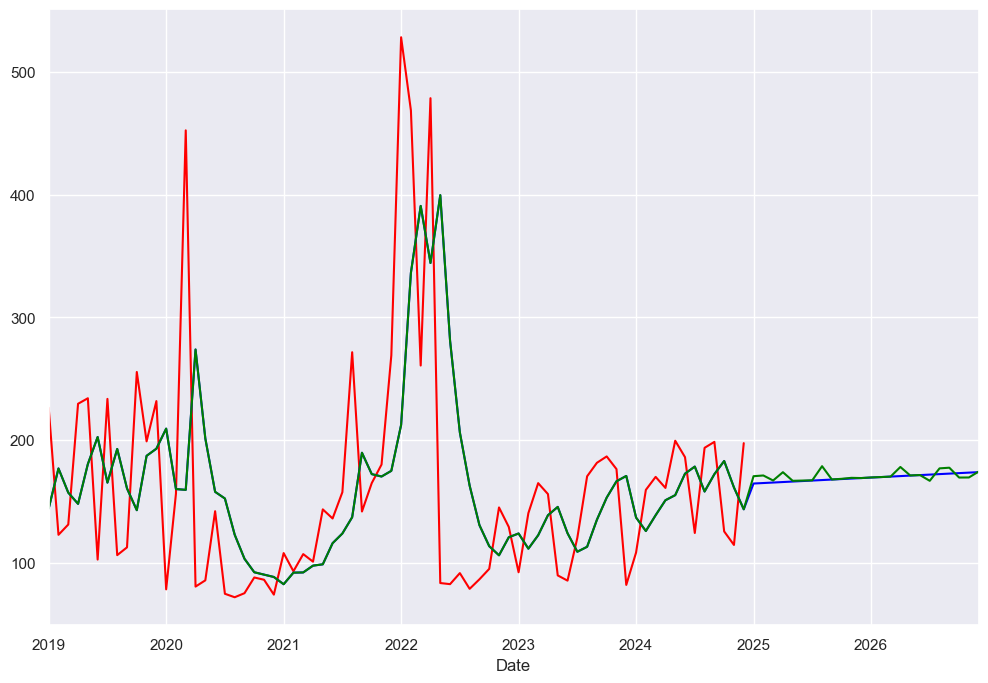

In [124]:
h=2*12 #M
w=h*3
data = z
model = sm.tsa.Holt
pred_index = data.index[-1] + np.array(range(1,h+1))
pred_rolling = pd.Series(0,index=pred_index)
pred_expanding = pd.Series(0,index=pred_index)
orig_fit = None
for i in range(0,h):
    current = pd.concat([data, pred_expanding.head(i)])
    expanding = model(current).fit()
    if i==0:
        orig_fit = expanding.fittedvalues
    rolling = model(current.tail(w)).fit()
    pred_expanding.update(expanding.forecast(1))
    pred_rolling.update(rolling.forecast(1))
ax = data[-w:].plot(color='red');#figsize=(9,6))
pd.concat([orig_fit[-w:],pred_expanding]).plot(ax=ax,color='blue');
pd.concat([orig_fit[-w:],pred_rolling]).plot(ax=ax,color='green');

The main goal of the chart is to compare the actual data and two different forecasting methods: expanding forecast and rolling forecast. 

ECSU time series data shows many periods of clear fluctuations from year to year, reflecting an unstable system affected by many factors. During the period **2019 to 2020, the series fluctuated slightly around 130–270, showing relative stability and no signs of strong changes. However, from 2021, the series began to show rapid increases and decreases, showing sensitivity to external factors such as market fluctuations or seasonal changes. Notably, 2022 was a period of clear instability with many spikes above 320, then sharply falling to nearly 100. These fluctuations create the image of a “jerky” series, without a clear trend, making forecasting difficult. By 2023, the chain continues to fluctuate erratically, with no longer having extremely high peaks but still having unexpected lows, reflecting a state of prolonged instability.

2024 is most notable for its sudden surge to above 500, setting the highest peak of the entire chain, and then falling very quickly to the average. This event is like a short-term “fever” or a market shock — a type of data bubble that bursts when it reaches its peak. From early 2025 to mid-year, the chain shows signs of settling down, fluctuating around 150–200. However, with the same erratic volatility as before, it is impossible to rule out the possibility of continued large fluctuations in the near future.

In [127]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

# **Holt-Winters Exponential Smoothing**

## Holt-Winters Additive

In [131]:
def hw_summary(model_sm):
    rmse_sm = sm.tools.eval_measures.rmse(model_sm.data.endog,model_sm.fittedvalues)
    print(' In-sample fit:')
    print(' RMSE               {0:.3f}'.format(rmse_sm))
    return model_sm.summary()

In [133]:
ahw_sm=sm.tsa.ExponentialSmoothing(y, trend='add', damped=False, 
                                   seasonal='add', seasonal_periods=12).fit()

C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\1345617319.py:1: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  ahw_sm=sm.tsa.ExponentialSmoothing(y, trend='add', damped=False,


In [135]:
hw_summary(ahw_sm)

 In-sample fit:
 RMSE               74.823


Dep. Variable:,ECSU,No. Observations:,228
Model:,ExponentialSmoothing,SSE,1276470.288
Optimized:,True,AIC,1999.700
Trend:,Additive,BIC,2054.570
Seasonal:,Additive,AICC,2002.973
Seasonal Periods:,12,Date:,"Wed, 02 Jul 2025"
Box-Cox:,False,Time:,14:10:11
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3684729,alpha,True
smoothing_trend,0.0315736,beta,True


## Holt-Winters Multiplicative

In [138]:
mhw_sm=sm.tsa.ExponentialSmoothing(y, trend='add', damped=False, seasonal='mul', seasonal_periods=12).fit()
hw_summary(mhw_sm)

C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\2535800595.py:1: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  mhw_sm=sm.tsa.ExponentialSmoothing(y, trend='add', damped=False, seasonal='mul', seasonal_periods=12).fit()


 In-sample fit:
 RMSE               74.296


Dep. Variable:,ECSU,No. Observations:,228
Model:,ExponentialSmoothing,SSE,1258538.402
Optimized:,True,AIC,1996.474
Trend:,Additive,BIC,2051.344
Seasonal:,Multiplicative,AICC,1999.747
Seasonal Periods:,12,Date:,"Wed, 02 Jul 2025"
Box-Cox:,False,Time:,14:10:13
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2875628,alpha,True
smoothing_trend,0.0192606,beta,True


## Holt-Winters with damped trend

In [141]:
mhw_damped=sm.tsa.ExponentialSmoothing(y, trend='add', damped=True, seasonal='mul', seasonal_periods=12).fit()
hw_summary(mhw_damped)

C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\686507242.py:1: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  mhw_damped=sm.tsa.ExponentialSmoothing(y, trend='add', damped=True, seasonal='mul', seasonal_periods=12).fit()


 In-sample fit:
 RMSE               73.453


Dep. Variable:,ECSU,No. Observations:,228
Model:,ExponentialSmoothing,SSE,1230154.967
Optimized:,True,AIC,1993.274
Trend:,Additive,BIC,2051.572
Seasonal:,Multiplicative,AICC,1996.927
Seasonal Periods:,12,Date:,"Wed, 02 Jul 2025"
Box-Cox:,False,Time:,14:10:16
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2875178,alpha,True
smoothing_trend,0.0001547,beta,True


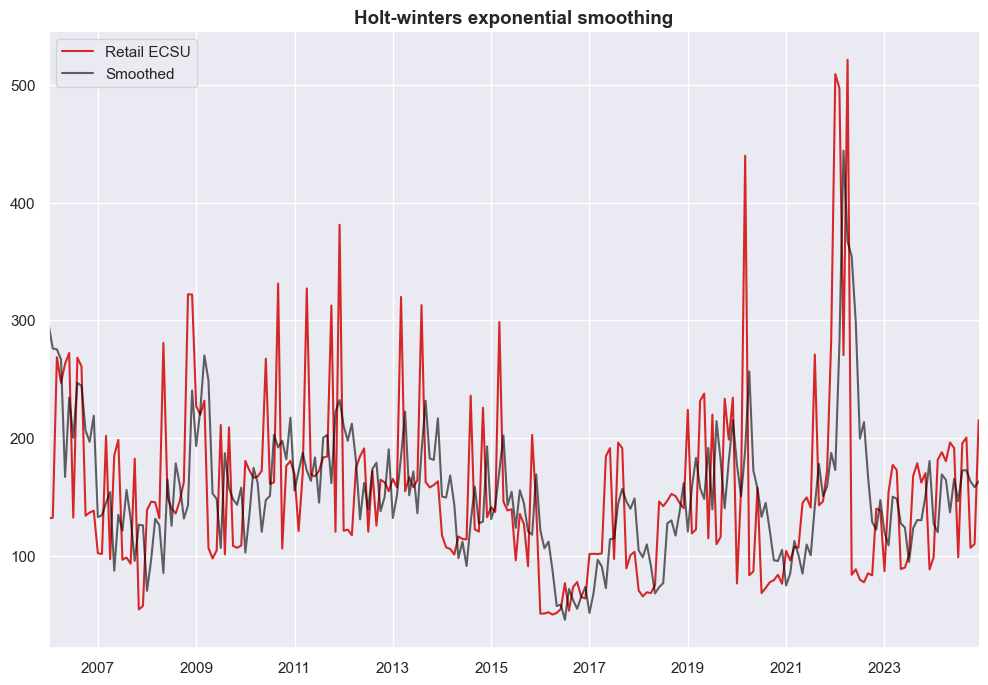

In [143]:
smoothed=pd.Series(mhw_sm.fittedvalues, index=y.index)

fig, ax= plt.subplots();#figsize=(9,6))

y['2006':].plot(color='#D62728', label='Retail ECSU')
smoothed['2006':].plot(color='black', label='Smoothed', alpha=0.6)
plt.legend(loc='best')
ax.set_xlabel('')
ax.set_xticks([], minor=True)
ax.set_title(r'Holt-winters exponential smoothing', fontsize=13.5, fontweight='bold')
sns.despine()
plt.show()

The chart clearly shows the evolution of retail sales (Retail ECSU) from 2006 to 2024 with notable features. The period 2007-2009 witnessed a sharp decline, due to the impact of the global financial crisis. From 2010 to 2019, sales showed a steady growth trend with clear seasonal cycles, especially recording outstanding growth in 2015-2016. The period 2020-2021 saw unusual fluctuations, reflecting the impact of the COVID-19 pandemic on retail activities. By 2022-2023, the data showed signs of recovery and stabilization. The smoothing curve from the Holt-Winters model follows both the long-term trend and the seasonal variations of the data quite well, but there are still small deviations at times of strong fluctuations such as the pandemic period. This result shows that Holt-Winters is an effective method for analyzing and forecasting data series with strong seasonal characteristics, especially suitable for short-term forecasting in the retail sector.

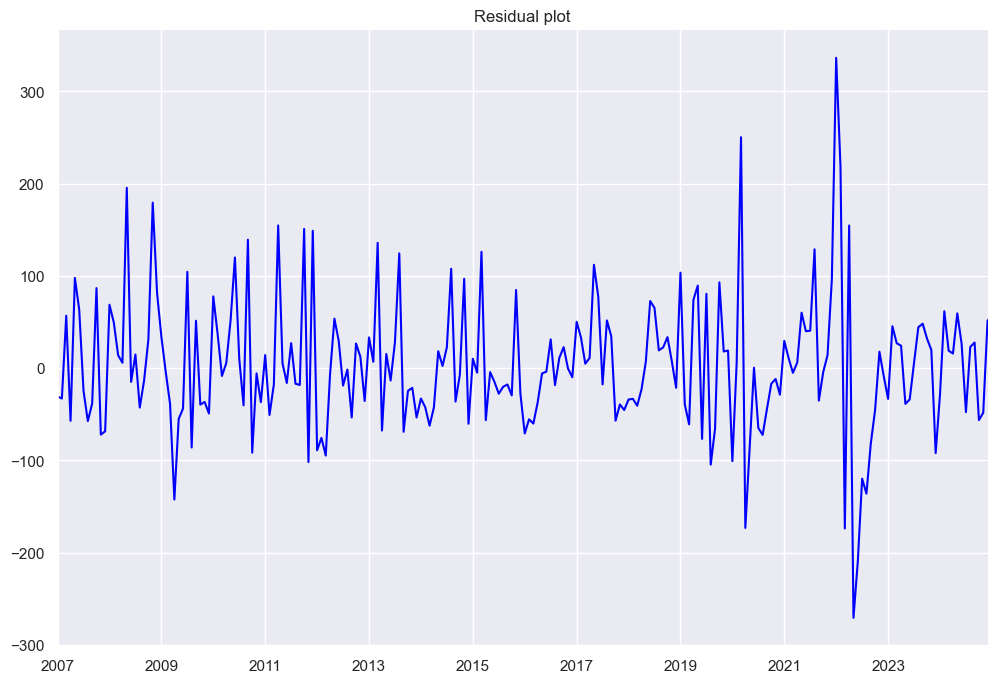

In [146]:
resid = (y-mhw_sm.fittedvalues)[12:] # we remove the first 12 observations as they are for initialisitation only

fig, ax= plt.subplots();#figsize=(9,6))
resid.plot(color='blue')
ax.set_xlabel('')
ax.set_xticks([], minor=True) 
ax.set_title('Residual plot')
sns.despine()
plt.show()

The chart above is a residual plot from the Holt-Winters model. The residuals are calculated by subtracting the model’s forecasted value from the actual value, showing the degree of deviation between the model and the actual value at each point in time.

Looking at the chart, we can see that the residuals fluctuate around zero, which is a good sign because it shows that the model does not have a clear bias in its forecasts. However, there are still some strong fluctuations, especially in 2020–2022, with some residual values ​​exceeding ±300. These large fluctuations may reflect unusual shocks in the real data that the Holt-Winters model does not handle well, such as sudden economic events.

In addition, the chart does not show a clear repeating pattern in the residuals, indicating that the model has captured the trend and seasonality factors quite well. However, some residuals have large and persistent amplitudes.

In conclusion, the Holt-Winters model performs quite well for most of the time, but still leaves large errors at times of strong fluctuations, reducing the accuracy during these periods. The residual plot is a useful tool to check the goodness of fit and the limits of the forecasting model.

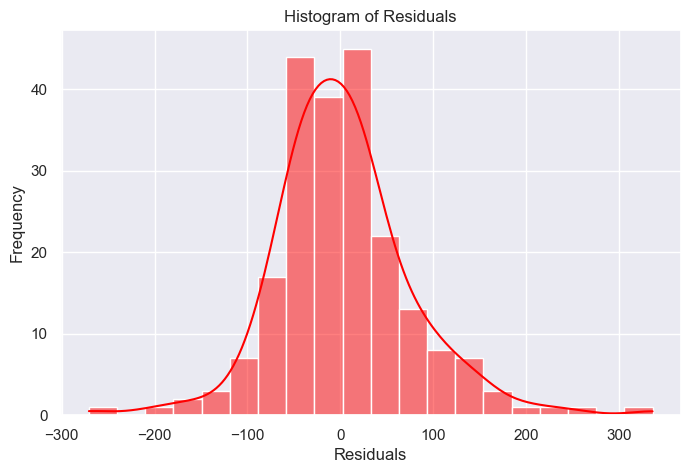

In [149]:
import seaborn as sns

def histogram(series, title='Histogram of Residuals'):
    plt.figure(figsize=(8, 5))
    sns.histplot(series.dropna(), kde=True, color='red', bins=20)
    plt.title(title)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.grid(True)

histogram(resid)
plt.show()


The above graph is a histogram of residuals from the Holt-Winters forecasting model, which helps to check whether the residuals follow a normal distribution — an important assumption in many forecasting models.

Looking at the histogram, we see that the distribution of residuals has a shape that is quite similar to a normal distribution, with a peak near 0 and symmetry on both sides. However, the residuals have longer tails to the right, indicating a slight right skewness. In addition, some residual values ​​fall far from the center (around ±200 to ±300), indicating the presence of outliers or large errors at some points.

Although the KDE curve (red line) closely follows the bell shape, the presence of extreme residuals suggests that the actual data has fluctuations that the model did not predict accurately. This may be due to unusual factors not captured by the model, such as unusual seasonal fluctuations or economic shocks.

Conclusion, the residuals from the model tend to be close to normal, but do not follow a perfect normal distribution due to the presence of skewness and outliers. This plot helps to check the validity of the normal distribution assumption in the errors and assess the reliability of the forecasting model.

In [152]:
start_val = y.index[-round(len(y)/12*.2)*12]
start_val

Period('2021-01', 'M')

In [154]:
# Real time forecasting 

validation=y[start_val:].index
start = y.index.get_loc(start_val) 

pred1 = [] # seasonal random walk
pred2 = [] # additive holt winters
pred3 = [] # multiplicative holt winters
actual= []

for i in range(start, len(y)):
    
    actual.append(y.iloc[i]) # actual value
    
    pred1.append(y.iloc[i-12]) # seasonal random walk forecast
    
    model = sm.tsa.ExponentialSmoothing(y.iloc[:i], trend='add', damped=False, seasonal='add', seasonal_periods=12).fit()
    pred2.append(model.forecast(1)[0]) # additive holt winters forecast
    
    model = sm.tsa.ExponentialSmoothing(y.iloc[:i], trend='add', damped=False, seasonal='mul', seasonal_periods=12).fit()
    pred3.append(model.forecast(1)[0]) # multiplicate holt winters forecast
    

columns=['Seasonal RW', 'Additive', 'Multiplicative', 'Actual']
results = np.vstack([pred1,pred2,pred3,actual]).T
results = pd.DataFrame(results, columns=columns, index=validation)

C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\1668488620.py:17: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model = sm.tsa.ExponentialSmoothing(y.iloc[:i], trend='add', damped=False, seasonal='add', seasonal_periods=12).fit()
C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\1668488620.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred2.append(model.forecast(1)[0]) # additive holt winters forecast
C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\1668488620.py:20: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model = sm.tsa.ExponentialSmoothing(y.iloc[:i], trend='add', damped=False, seasonal='mul', seasonal_periods=12).fit()
C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\1668488620.py:21: FutureWa

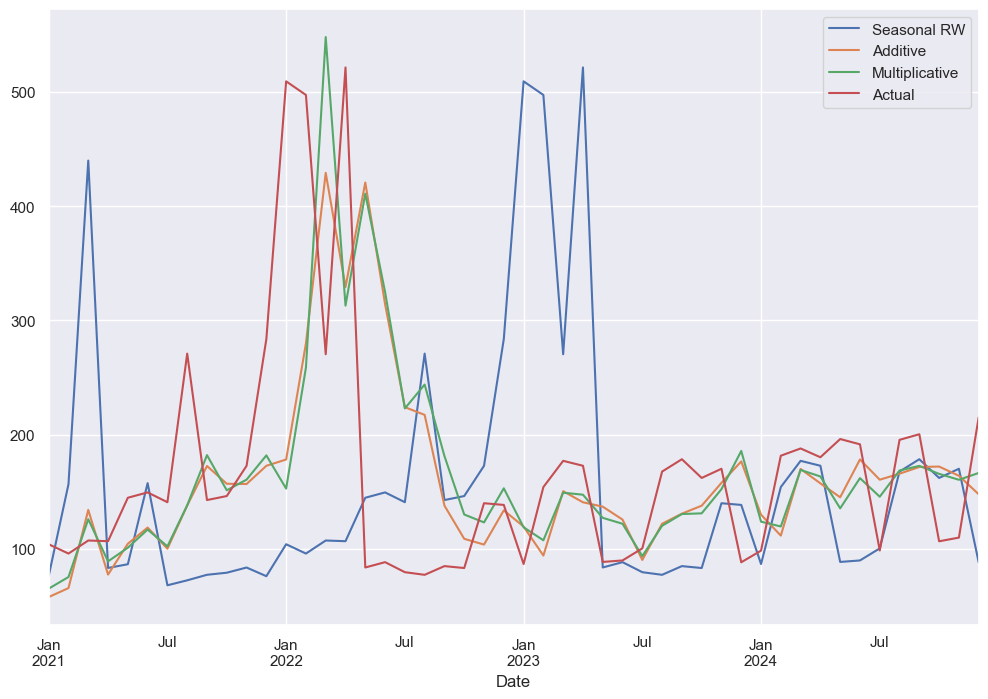

In [156]:
results.plot();


The chart shows the evolution and forecast of the ECSU index from 2021 to 2024 with four lines: actual data, Seasonal Random Walk, Additive and Multiplicative models. Looking closely, we can see that the actual data line is characterized by strong fluctuations and instability, with sharp peaks around mid-2021 and early 2022, reaching a high of more than 500. Immediately following these peaks are sharp declines below 100, showing large and irregular fluctuations in the data series.

From mid-2022 onwards, the actual index begins to stabilize with a narrower range of fluctuations, mainly fluctuating between 100 and 200. Both the Additive and Multiplicative models begin to show a fairly good grip on real data during this period, with smooth curves that reflect the general trend without being disturbed by sharp peaks like in the Random Walk model. In particular, the Multiplicative model tends to react better at points of gentle slope changes, helping to simulate the up-down cycle more reasonably. The Seasonal RW model, although sensitive to fluctuations, over-reflects, creating large peaks that are not consistent with the actual data, especially in 2022 and 2023. Meanwhile, Additive and Multiplicative tend to follow the actual data more closely in the period after 2022, describing relatively accurately the cycles of slight increases at the beginning of the year and decreases at the end of the year - a seasonal cyclical feature. The fluctuations of the decomposition models reflect the long-term trend and eliminate short-term noise factors, which is good for forecasting.

In summary, the chart shows that ECSU data has strong fluctuations in the early stages, then gradually stabilizes, and the Multiplicative model is able to simulate the ups and downs of this series most accurately thanks to its flexibility in handling the relationship between trends and seasonal factors.

In [158]:
import pandas as pd

results = {
    "Model": ['Holt-Winters Additive','Holt-Winters Multiplicative','Holt-Winters with damped trend'],
    'AIC': [1999.7,1996.474,1993.274],
}

summary_table = pd.DataFrame(results)
display(summary_table.style.set_caption('Summary table'))

,Model,AIC
0,Holt-Winters Additive,1999.700000
1,Holt-Winters Multiplicative,1996.474000
2,Holt-Winters with damped trend,1993.274000


- From there, I can conclude Holt-Winters with damped trend is the best model of 3 models because AIC for Hotl-Winters with damped trend is smallest.

C:\Users\Ntngan2601\AppData\Local\Temp\ipykernel_30256\3635348260.py:4: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model = sm.tsa.ExponentialSmoothing(y,


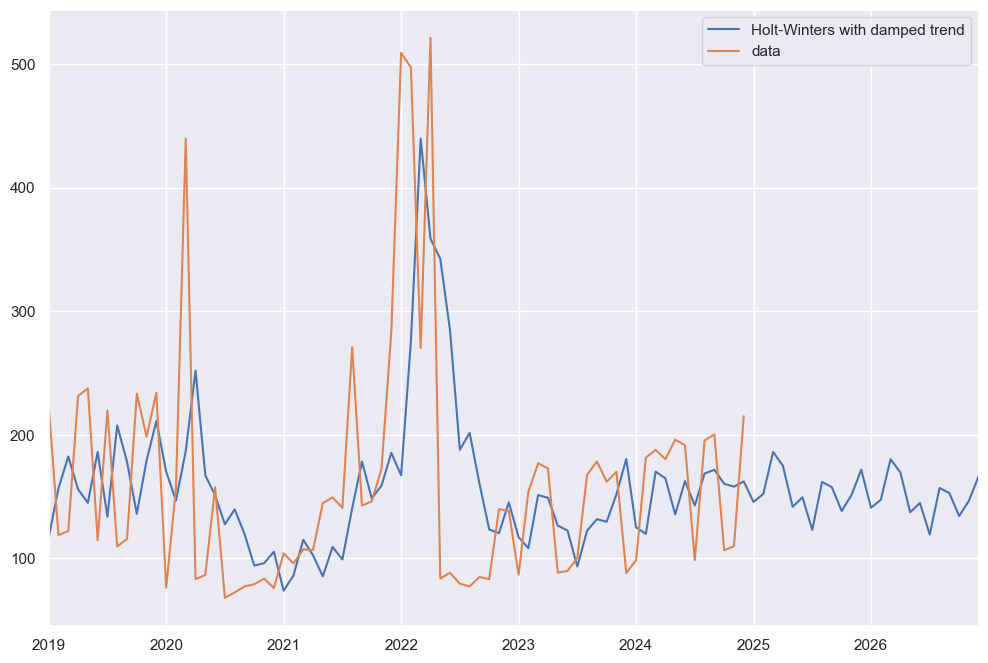

In [161]:
h=2*12 #M
w=h*3

model = sm.tsa.ExponentialSmoothing(y, 
                    trend='add', damped=True, seasonal='mul', seasonal_periods=12).fit()

plot = pd.DataFrame()
plot['Holt-Winters with damped trend'] = pd.concat([model.fittedvalues, model.forecast(h)])
plot['data'] = y

plot[-(w+h):].plot();#figsize=(9,6))

The chart above shows the forecast results of the `ECSU` data series using the Holt-Winters model with a damped trend, compared to the actual data series from 2019 to mid-2026. In the early period (2019–2020), the actual data series fluctuated around 150–250, reflecting moderate volatility. Starting from 2020 to 2022, the series appeared to be highly volatile, with peaks exceeding 400 and reaching a maximum of over 500 around 2022. After this point, the series dropped below 100, then recovered slightly but still fluctuated in the range of 100–200 until 2024.

The Holt-Winters model with a damped trend forecasts the trend of the series quite closely in the early and middle periods, especially in long-term uptrends or downtrends. However, at the spikes (abnormal peaks and troughs), the model fails to keep up with the rate of change, reflecting the model’s limitations when faced with abnormal shocks. Starting in 2024, the model forecasts a gradual stabilization, oscillating around the mean of around 150 with no significant change — a typical characteristic of a damped trend model, which assumes that trends will lose their influence over time.

# **SARIMA Model**

## **100% testing**

In [182]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
!pip install pmdarima

In [184]:
from pmdarima import auto_arima
import pandas as pd

series = df['ECSU'].dropna()

# Tự động xác định thông số SARIMA tốt nhất
model = auto_arima(series,
                   seasonal=True,
                   m=12,                # Chu kỳ mùa vụ = 12 tháng
                   max_p=3, max_q=3,    # Giới hạn hệ số không mùa
                   max_P=3, max_Q=3,    # Giới hạn hệ số mùa vụ
                   max_d=2, max_D=1,    # Cho phép tối đa 2 lần sai phân, 1 lần sai phân mùa
                   stepwise=True,       # Chạy nhanh
                   trace=True,          # In quá trình chọn mô hình
                   suppress_warnings=True,
                   error_action='ignore')  # Bỏ qua lỗi convergence

# In mô hình tối ưu
print("\n>>> SARIMA Model Selected:")
print(model.summary())

# In thông số để dùng với SARIMAX
print("\n>>> Use with SARIMAX:")
print("order =", model.order)
print("seasonal_order =", model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.06 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2636.014, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2606.358, Time=2.07 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2615.082, Time=0.50 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3000.454, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2605.113, Time=0.10 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=2606.292, Time=0.17 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=2608.268, Time=0.69 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=2599.062, Time=0.10 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=2600.092, Time=3.26 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=2599.967, Time=0.35 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=2601.932, Time=0.81 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=2595.483, Time=0.08 sec
 ARIMA(3,0,0)(1,0,0)[12] intercept   : AIC=2596.800, Time=3.80 sec
 ARIMA(3,0,0)(0,0,1)[12]

The results show oder=(3,0,0) and seasonal_order=(0,0,0,12) that SARIMA is best at this point, so I will use that point to run the SARIMA model according to the code below.

In [187]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(df['ECSU'],
                       order=(3,0,0),
                       seasonal_order=(0,0,0, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit()
print(sarima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   ECSU   No. Observations:                  228
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -1287.486
Date:                Wed, 02 Jul 2025   AIC                           2582.971
Time:                        14:12:38   BIC                           2596.636
Sample:                             0   HQIC                          2588.486
                                - 228                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3994      0.042      9.443      0.000       0.317       0.482
ar.L2          0.2582      0.049      5.310      0.000       0.163       0.354
ar.L3          0.2867      0.049      5.860      0.0

1. **AR:**
- ar.L1 = 0.3994, p-value=0.000
=> The first-order AR coefficient is statistically significant (p-value < 0.05), showing that the current value of the series has a close relationship with the value 1 period before. Specifically, when the value at time t-1 increases by 1 unit, the current value will increase by an average of 0.3994 units (keeping other factors constant).

- ar.L2= 0.2582, p-value= 0.000
=> The quadratic AR coefficient is also statistically significant. The present value is affected by the value at time t-2, with an impact coefficient of 0.2582.
- ar.L3 = 0.2867, p-value= 0.000  
=> Reject H0 at time t-3 affects the present value, with a coefficient of 0.2867.
- Conclusion: All three AR coefficients are statistically significant (as p-values ​​are all = 0.000), and have positive coefficients → the model shows that the series has strong autoregressive properties in the first 3 lags.

2. - sigma2= 5466.7540

=> This is the error variance in the model. This value indicates the amount of unexplained variation in the model. The smaller this value, the better the model fits (less error).

3. -  Ljung-Box test (Q = 0.19, Prob = 0.66)

=> Check whether the residuals are still autocorrelated.

Because p-value = 0.66 > 0.05, we do not reject H0, meaning the residuals are not autocorrelated, showing that the model has handled the relationship in the time series well.

4. - Jarque-Bera test (JB = 119.46, p-value = 0.00)
     
  =>Test for normal distribution of residuals.
  
p-value = 0.00 < 0.05 ⇒ reject H0 ⇒ residuals do not follow normal distribution, this is a sign that the model may not be completely suitable.

5. -  Heteroskedasticity test (H = 1.53, p-value = 0.07)
     
=> Test whether the error variance is constant or not.

p-value = 0.07 > 0.05, we do not reject H0 ⇒ the error variance can be considered constant, meaning the residuals are relatively stable.

- From there, I have result of AIC = 2582.971

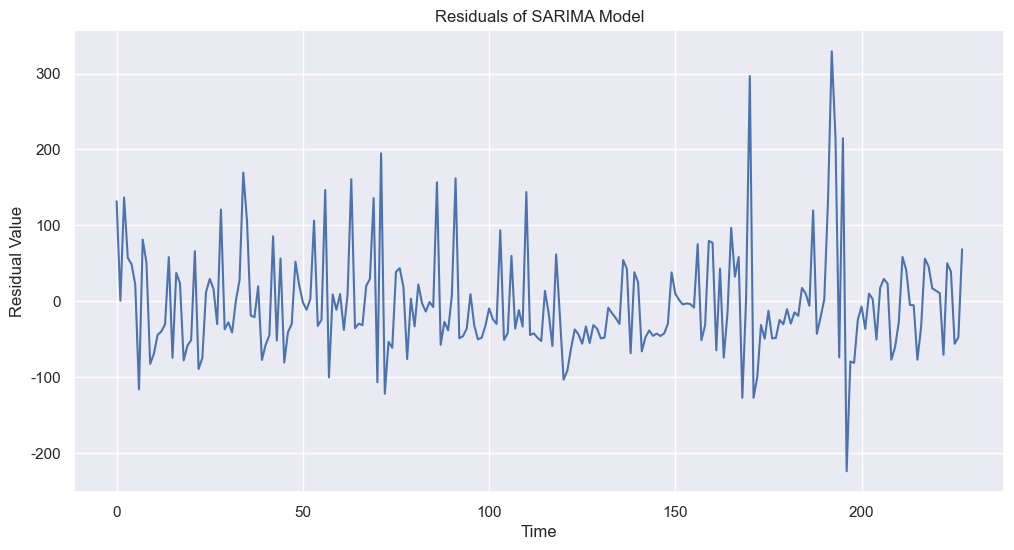

In [191]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # Thêm dòng import này

plt.figure(figsize=(12, 6))

# Format y-axis với dấu phân cách hàng nghìn
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))

plt.plot(residuals)
plt.title('Residuals of SARIMA Model')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.grid(True)
plt.show()

In the early stage (years 1-50), the residuals fluctuated quite stably around -50, with only a few peaks dropping slightly to -100. However, when entering the middle stage (years 50-150), the chart recorded strong fluctuations with many deep drops to -200 to -300, interspersed with short-term recoveries. In particular, around year 100, there was a sharpest drop to -300, suggesting that the model may not have captured some unusual factors in this stage.

When moving to the late stage (years 150-200), although still remaining negative, the amplitude of the fluctuations was more stable, mainly in the range of -100 to -200 and no longer had extreme fluctuations like in the previous stage. This may reflect model adjustments or changes in the nature of the data series. However, the overall trend is still negative, suggesting the possibility of systematic bias that needs to be further examined.

These fluctuations are particularly noticeable in the middle period, when the residuals continuously fluctuate strongly, suggesting the possibility of anomalies or structural changes in the time series during this period. This suggests that the model may need to be adjusted to better handle strong fluctuations in the future.

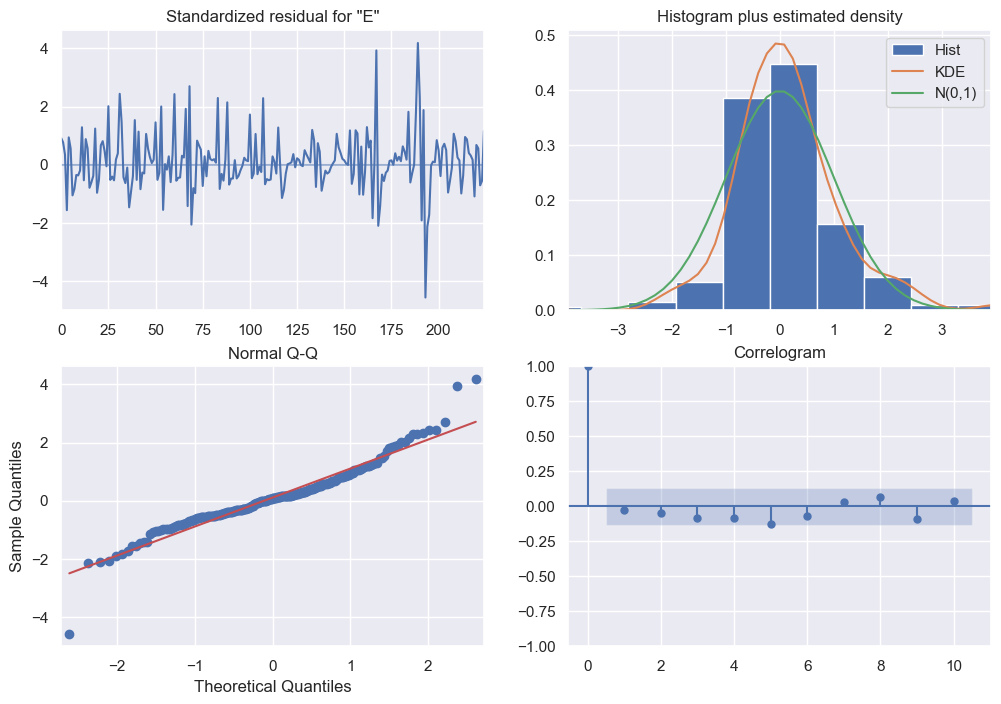

In [194]:
# Diagnostics plot for SARIMA
sarima_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

The diagnostic plot of the SARIMA model provides a comprehensive view of the residuals, thereby allowing for an assessment of the model’s adequacy and accuracy. The first plot (top-left) shows the standardized residuals over time, which fluctuate around zero without any clear upward or downward trend and no prolonged runs of positive or negative values. This suggests that the model has effectively captured the underlying structure of the data, leaving residuals that resemble random noise — a positive sign of a well-fitting model.

The histogram is a histogram of residuals overlaid with a kernel density estimate (KDE). The residuals appear to be fairly symmetrically distributed around zero, and the KDE curve closely follows the normal curve. This supports the assumption that the residuals follow a normal distribution — an important condition for reliable forecasting in time series models.

The Q-Q plot  displays the relationship between the theoretical quantiles of a normal distribution and the sample quantiles of the residuals. Most points lie close to the 45-degree reference line, especially in the center of the distribution, indicating that the residuals are approximately normally distributed. Slight deviations at the tails are common and generally acceptable in practical applications.

Finally, the autocorrelation function (ACF) plot of the residuals (bottom-right) shows that most autocorrelation bars fall within the 95% confidence bands (blue shaded area). This means that there is no significant autocorrelation in the residuals, indicating that the model has successfully captured the time-dependent structure in the data and that the residuals resemble white noise.



## **20% test và 80% train**

In [198]:
# Define the split point (last 13 weeks for testing)
test_size = 50
train_data = series[:-test_size]
test_data =series[-test_size:]

In [200]:
# Train SARIMA model on TRAINING DATA only (đã sửa)
sarima_model = SARIMAX(train_data,  
                      order=(3, 0, 0),
                      seasonal_order=(0, 0, 0, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

# Fit model
sarima_fit = sarima_model.fit(disp=False)


In [202]:
# Forecast for the test period
forecast = sarima_fit.get_forecast(steps=test_size)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
forecast_mean.index = test_data.index

In [204]:
# Evaluate model performance
mad = mean_absolute_error(test_data, forecast_mean)
mse = mean_squared_error(test_data, forecast_mean)
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))
mape = np.mean(np.abs((test_data - forecast_mean) / test_data)) * 100

print(f"Mean Absolute Error (MAD): {mad:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAD): 120.90
Mean Squared Error (MSE): 25123.72
Root Mean Squared Error (RMSE): 158.50
Mean Absolute Percentage Error (MAPE): 66.17%


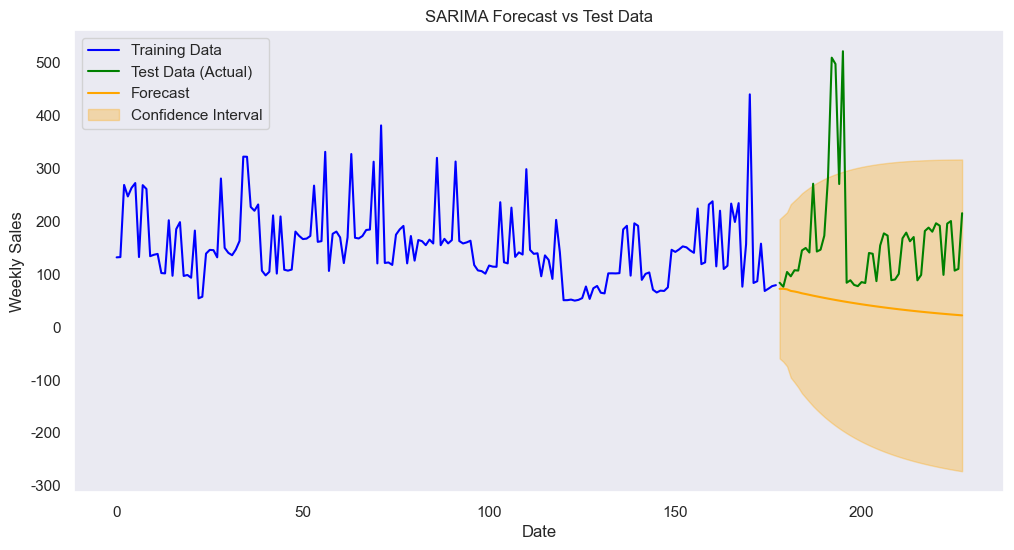

In [206]:
# Plot the forecast and test data
plt.figure(figsize=(12, 6))

# Plot training data
plt.plot(train_data, label='Training Data', color='blue')

# Plot test data
plt.plot(test_data, label='Test Data (Actual)', color='green')

# Plot forecasted values
plt.plot(test_data.index, forecast_mean, label='Forecast', color='orange')

# Plot confidence intervals
plt.fill_between(test_data.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='orange', alpha=0.3, label='Confidence Interval')

# Format y-axis
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))

plt.title('SARIMA Forecast vs Test Data')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid()
plt.show()

The above graph shows the forecast results of the SARIMA model compared to the actual data in the validation period. The blue line represents the training data, while the green line represents the actual data of the testing period. The orange line represents the forecast value from the SARIMA model, with the light orange stripe representing the 95% confidence interval.

Observing the training data from the beginning of the series up to around point 180 shows that the time series fluctuates strongly with many irregular ups and downs. There are significant peaks around the middle of the series (points 50–100), where the value reaches above 300 units, indicating short-term spikes. However, this is followed by a period of decline, with low fluctuations below 150 units, followed by a number of short peaks at the end of the training period.

The testing period starts from around point 180 onwards. Here, the real data (green line) shows extremely strong volatility, with some points exceeding 500, which is much higher than the average of the training series. Meanwhile, the SARIMA model predicts a slight decrease after the training period, which is clearly shown by the downward sloping orange line. The confidence interval gradually widens over time, especially at the bottom, reflecting the increasing uncertainty in the further forecasts.

From this graph, we can draw some important conclusions. First, the SARIMA model has learned the basic characteristics of the time series during the training period, but has difficulty keeping up with the extreme fluctuations in the test data. Second, the increasing width of the confidence interval is reasonable because the uncertainty is always higher in the longer-term forecasts.

## **Grid Search for Parameter Optimization**

In [210]:
import itertools

In [212]:
# Define the parameter ranges
p = [0, 1, 2, 3]
d = [0]
q = [0, 1, 2, 3]
P = [0, 1, 2]
D = [1]
Q = [0, 1, 2]
m = 12

# Generate all combinations of parameters
parameter_combinations = list(itertools.product(p, d, q, P, D, Q))

In [214]:
# Placeholder for results
results = []

# Iterate over all combinations of parameters
for param in parameter_combinations:
    try:
        model = SARIMAX(series,
                        order=(param[0], param[1], param[2]),
                        seasonal_order=(param[3], param[4], param[5], m),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        model_fit = model.fit(disp=False)

        results.append((param, model_fit.aic))
    except Exception as e:
        continue

C:\Users\Ntngan2601\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Ntngan2601\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Ntngan2601\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Ntngan2601\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Ntngan2601\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [216]:
# Find the best combination
best_params = sorted(results, key=lambda x: x[1])[0]

print(f"Best Parameters: {best_params[0]}")
print(f"Best AIC: {best_params[1]}")

Best Parameters: (1, 0, 3, 1, 1, 2)
Best AIC: 2173.18367655572


In [218]:
# Initialize the SARIMA model with the best parameters
optimized_model = SARIMAX(series,
                          order=(1,0,3),
                          seasonal_order=(1,1,2,12),
                          enforce_stationarity=False,
                          enforce_invertibility=False)

optimized_fit = optimized_model.fit(disp=False)

In [220]:
# Fit the model using the Powell optimization method to avoid convergence error
optimized_fit = optimized_model.fit(disp=False, method='powell')

In [222]:
# Print the summary of the optimized model
print(optimized_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                    ECSU   No. Observations:                  228
Model:             SARIMAX(1, 0, 3)x(1, 1, [1, 2], 12)   Log Likelihood               -1078.611
Date:                                 Wed, 02 Jul 2025   AIC                           2173.223
Time:                                         14:19:03   BIC                           2199.114
Sample:                                              0   HQIC                          2183.713
                                                 - 228                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3669      0.214      1.717      0.086      -0.052       0

The ar.L1 coefficient (autoregression of order 1) has a value of 0.3669, indicating that the current value tends to be positively affected by the value of the previous month. However, the p-value is 0.086 > 0.05, so this coefficient is not statistically significant at the 5% significance level.

The ma.L1 coefficient is -0.1037 and is not statistically significant (p = 0.637), indicating that the moving average component of order 1 does not play an important role in forecasting the series. Meanwhile, ma.L2 and ma.L3 are both statistically significant (p is 0.004 and 0.003, respectively), indicating that the errors from 2 and 3 months ago have a significant impact on the current value, and are effectively exploited by the model to improve the forecasting accuracy.

In the seasonal part, the coefficient ar.S.L12 (seasonal AR in lag 12) has a value of -0.6787 and is statistically significant (p = 0.031), which indicates that the seasonal factor from the previous 12 months has a significant negative effect on the current value, that is, when the value of the previous 12 months increases, the current value tends to decrease. The coefficients ma.S.L12 and ma.S.L24 are both statistically insignificant (p-values ​​are 0.923 and 0.751, respectively), indicating that seasonal error components do not play a major role in the current model.

The variance of the error (sigma2) is very large (4914.8738), reflecting high volatility in the data series or possibly due to the measurement unit of the dependent variable.

Statistical tests show that the residuals of the model:

Ljung-Box has p-value = 0.95 → there is no residual autocorrelation in the residuals, the model has handled the time-dependent structure well.

Jarque-Bera has a very large value (JB = 214.15) with p-value close to 0, indicating that the residuals are not normally distributed, which may affect the effectiveness of some statistical inferences.

Heteroskedasticity test with p = 0.02 → the residuals show signs of heteroskedasticity.

In addition, the skewness is 1.47 and the kurtosis is 7.32, indicating that the residuals are skewed to the right and have longer tails than the normal distribution.

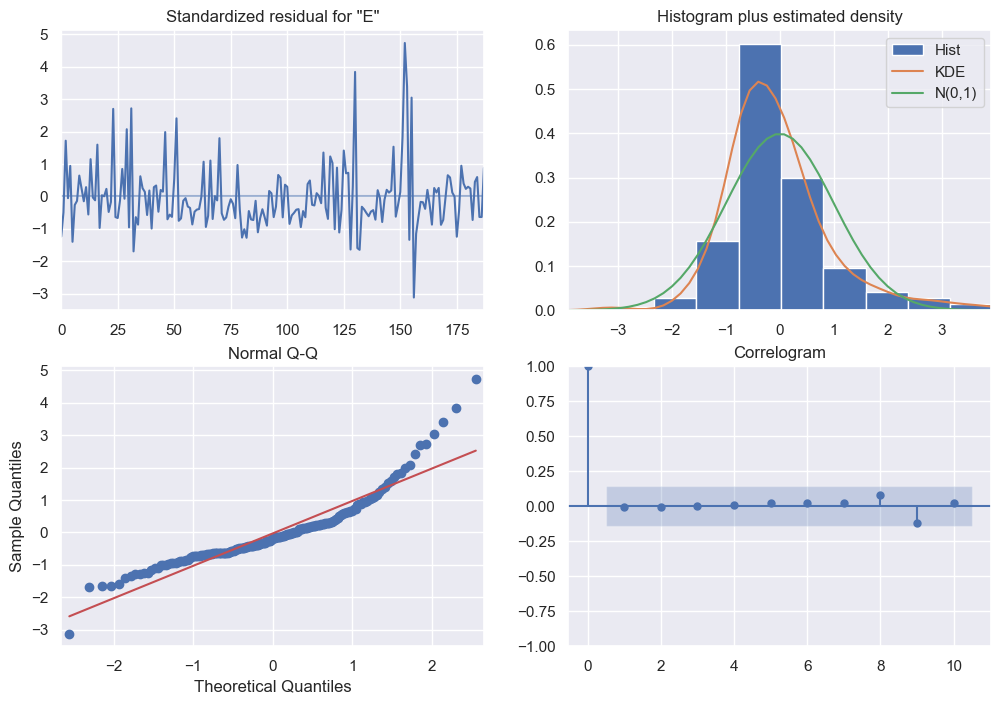

In [225]:
# Plot diagnostic graphs for residual analysis
optimized_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

1. Standardized Residuals
This plot shows the standardized residuals over time. It is observed that the residuals fluctuate around the zero axis, mostly in the range [-2, 2], except for a few outliers (2020–2022) that exceed the threshold of ±3. This shows that the model has largely captured the trend and seasonality, but there are still some points where the model has not forecasted accurately (due to the economic crisis)

2. Histogram with KDE & N(0,1)
The histogram plot combined with the kernel density (KDE) and the standardized normal distribution N(0,1) shows that the residuals are distributed almost like a normal distribution, although slightly skewed to the left. The KDE line is slightly higher than the standard at the center, but the difference is not large. Overall, this is a positive sign because the assumption of normally distributed residuals is almost satisfied.

3. Normal Q-Q Plot 
The Q-Q plot compares the actual distribution of the residuals with the normal distribution. The observations are close to the diagonal, especially in the central region. However, at the two ends of the distribution (left and right tails), there are a few points that deviate significantly from the diagonal. This shows that the residuals have some slight deviations from the normal distribution, mainly due to the presence of outliers. However, the majority of the data still fits the normal distribution well.

4. Correlogram 
The residual autocorrelation plot (ACF) shows that the autocorrelation coefficients are all within the confidence interval (light blue area), except for lag = 1. This shows that the residuals are almost completely autocorrelated, which means that the SARIMAX model has handled the time structure in the data well. This is an important criterion for confirming the model fit.

**Conclusion:**
The selected SARIMAX model captures the characteristics of the time series quite well, including trend, seasonality, and autocorrelation.

The residuals are almost normally distributed, have no significant autocorrelation, and fluctuate steadily around 0 → which is a sign that the model is suitable.

# Moving average model

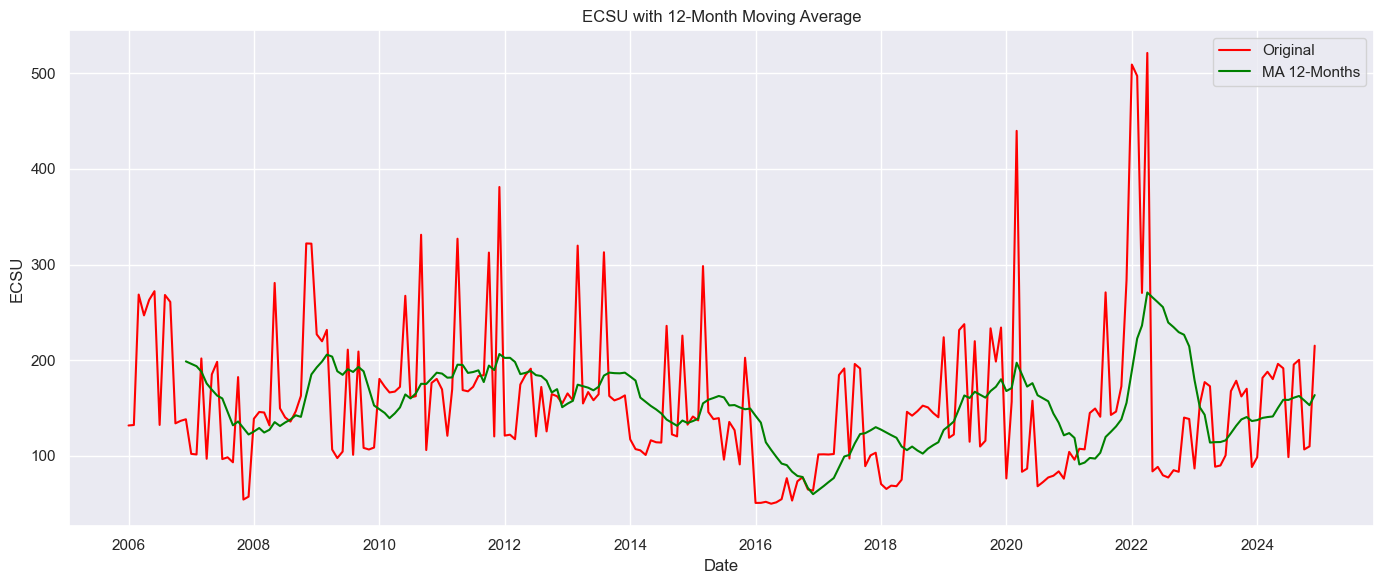

=== Forecast error metrics for 12-month Moving Average ===
MAD : 53.30
MSE : 5410.34
RMSE : 73.56
MAPE : 41.22%


In [237]:
df = pd.read_excel("ECSU.xlsx")

# Chuyển cột Date sang kiểu datetime
df['Date'] = pd.to_datetime(df['Date'])


# Tính MA 12 tháng
df['MA_12'] = df['ECSU'].rolling(window=12).mean()

# Vẽ biểu đồ
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['ECSU'], label='Original', color='red')
plt.plot(df['Date'], df['MA_12'], label='MA 12-Months', color='green')

plt.title('ECSU with 12-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('ECSU')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
import pandas as pd
import numpy as np

# Tính các sai số dự báo
errors = df['ECSU'] - df['MA_12']
mad  = np.mean(np.abs(errors))                       
mse  = np.mean(errors**2)                     
rmse = np.sqrt(mse)                                  
mape = np.mean(np.abs(errors / df['ECSU'])) * 100

# In kết quả
print("=== Forecast error metrics for 12-month Moving Average ===")
print(f"MAD : {mad:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

The chart above illustrates the original ECSU data series and the 12-month moving average over the period from 2006 to 2024. The ECSU data shows strong fluctuations with many clear peaks and troughs, especially in 2012, 2021, and 2022 when the value spiked above 400, even surpassing 500. Meanwhile, the 12-month MA shows a smoother trend, helping to identify long-term movements such as the decline from 2014 to 2016, the rebound from 2018 to 2022, and the subsequent decline. However, due to the smoothing nature, the MA is slow to react to sudden fluctuations. The results of the accuracy assessment of the 12-month MA method show a relatively high error: MAD is 53.30, RMSE is 73.56 and especially MAPE is up to 41.22%, showing that the average difference between the forecast and actual values ​​is still large. Thus, the 12-month moving average method is more suitable for analyzing overall trends than for short-term forecasting.

# Exponential Smoothing model

C:\Users\Ntngan2601\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


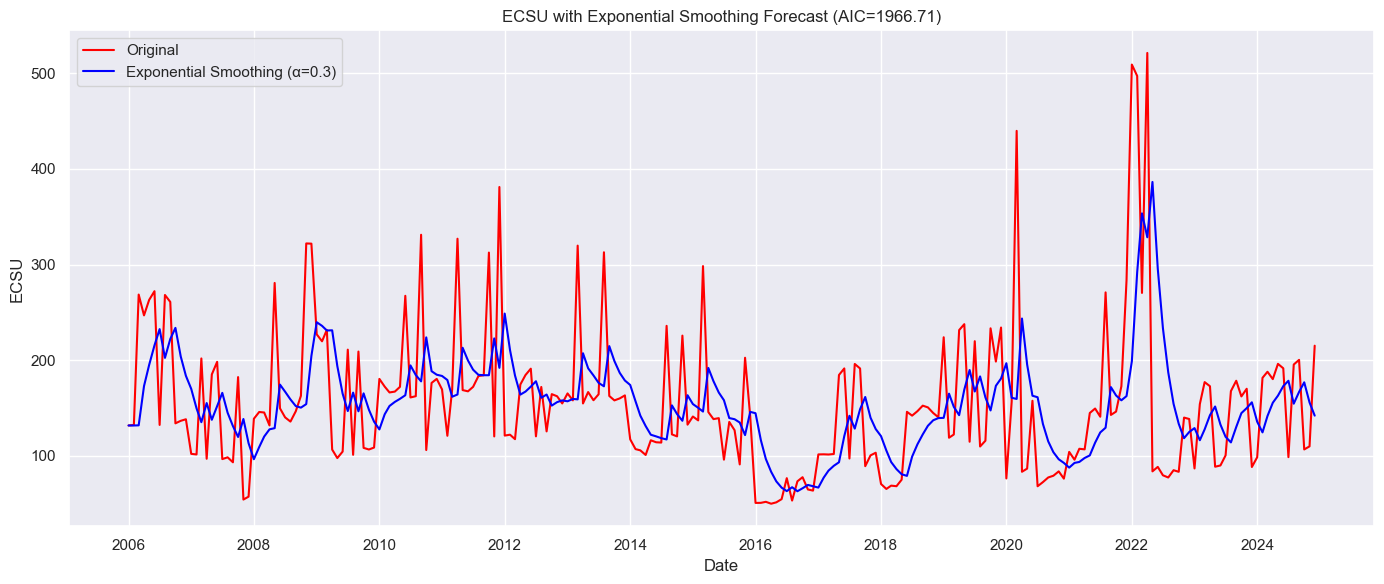

=== Exponential Smoothing Model ===
Smoothing parameter (α): 0.30
AIC: 1966.71

=== Optimized Model ===
Optimized smoothing parameter (α): 0.3
Optimized AIC: 1966.39


In [241]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. Đọc và chuẩn bị dữ liệu
df = pd.read_excel("ECSU.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 2. Áp dụng Exponential Smoothing
# Chọn giá trị smoothing_level (alpha) - thường chọn từ 0.1 đến 0.3
alpha = 0.3  

# Tạo và fit mô hình
model = SimpleExpSmoothing(df['ECSU'])
fit_model = model.fit(smoothing_level=alpha, optimized=False)
df['ES'] = fit_model.fittedvalues

# 3. Tính AIC
aic = fit_model.aic  # Lấy giá trị AIC từ mô hình đã fit

# 4. Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['ECSU'], label='Original', color='red')
plt.plot(df.index, df['ES'], label=f'Exponential Smoothing (α={alpha})', color='blue')
plt.title(f'ECSU with Exponential Smoothing Forecast (AIC={aic:.2f})')
plt.xlabel('Date')
plt.ylabel('ECSU')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. In kết quả AIC
print("=== Exponential Smoothing Model ===")
print(f"Smoothing parameter (α): {alpha:.2f}")
print(f"AIC: {aic:.2f}")

# 6. Tự động tìm giá trị alpha tối ưu và tính AIC (tùy chọn)
optimized_model = model.fit()  # Để statsmodels tự tìm alpha tối ưu
best_alpha = optimized_model.model.params['smoothing_level']
optimized_aic = optimized_model.aic

print("\n=== Optimized Model ===")
print(f"Optimized smoothing parameter (α): {best_alpha:.1f}")
print(f"Optimized AIC: {optimized_aic:.2f}")

The above graph shows a comparison between the original time series of the variable ECSU and the series smoothed by the Exponential Smoothing method with a smoothing coefficient of α = 0.3. The data series spans from 2006 to 2024.

From 2006 to around 2015, the ECSU series tends to fluctuate quite strongly, with many sudden peaks and troughs, with large amplitudes, especially in the period 2008–2010 and 2012–2014. The blue line (Exponential Smoothing) shows that the smoothing model has reduced most of the noise and short-term fluctuations, reflecting the overall trend more stably.

From 2016 onwards, the series continued to maintain a strong fluctuation trend, especially in the period 2020–2022, with large shocks with peaks above 500 – this period shows an unusual spike in ECSU. Although the Exponential Smoothing model cannot accurately reproduce the large spikes, it still follows the average trend and provides a smoother view of the long-term behavior of the series.

**AIC ≈ 1966.71** shows the model's fit to the data, a low AIC value is a good sign in model evaluation. However, the Exponential Smoothing method with α=0.3 still has a certain delay in responding to sudden fluctuations.

**Conclusion:** The Exponential Smoothing model helps to highlight the overall trend of the ECSU series and is suitable for medium-term stable forecasting goals.

# Weighted Moving Average model

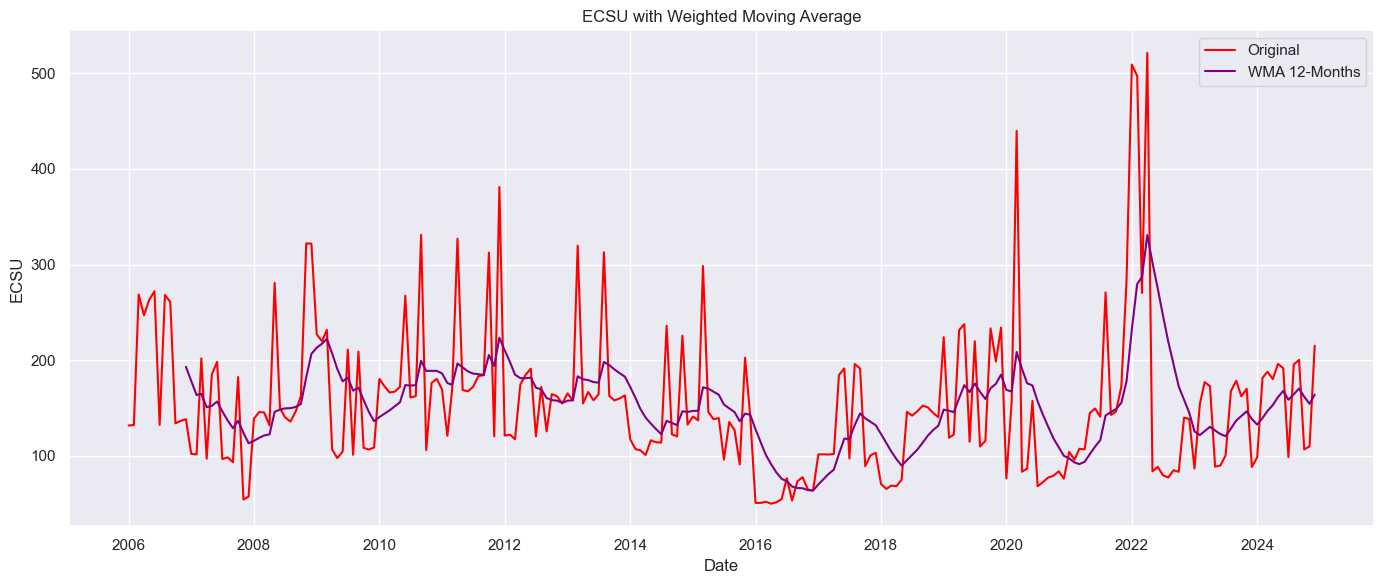

=== Forecast error metrics for Weighted Moving Average ===
Window size: 12 months
MAD : 46.32
MSE : 4190.03
RMSE : 64.73
MAPE : 35.38%


In [244]:
# 2. Hàm tính Weighted Moving Average
def weighted_moving_average(series, window=12):
    """
    Tính Weighted Moving Average với trọng số giảm tuyến tính
    Trọng số: [1, 2, 3, ..., window] / sum(1+2+...+window)
    """
    weights = np.arange(1, window + 1)
    weights = weights / weights.sum()  # Chuẩn hóa tổng trọng số = 1
    
    return series.rolling(window=window).apply(lambda x: np.sum(weights * x), raw=True)

# 3. Tính WMA 12 tháng
window_size = 12
df['WMA_12'] = weighted_moving_average(df['ECSU'], window=window_size)

# 4. Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['ECSU'], label='Original', color='red')
plt.plot(df.index, df['WMA_12'], label=f'WMA {window_size}-Months', color='purple')

plt.title('ECSU with Weighted Moving Average')
plt.xlabel('Date')
plt.ylabel('ECSU')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Tính các sai số dự báo
errors = df['ECSU'] - df['WMA_12']
mad = np.mean(np.abs(errors.dropna()))                       
mse = np.mean(errors.dropna()**2)                     
rmse = np.sqrt(mse)                                  
mape = np.mean(np.abs(errors.dropna() / df['ECSU'].dropna())) * 100
print("=== Forecast error metrics for Weighted Moving Average ===")
print(f"Window size: {window_size} months")
print(f"MAD : {mad:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


The chart shows the ECSU data series and the 12-month Weighted Moving Average from 2006 to 2024. The red line represents the original data with strong fluctuations and sharp peaks, while the purple line represents the series that has been smoothed by giving greater weight to values ​​closer to the present, reflecting a more stable overall trend.

**2006–2008 period:**
The original data has strong fluctuations, with peaks around 250 and troughs near 100. However, the WMA line remains stable around 170–200, demonstrating the good smoothing ability of the WMA method.

**2009–2012 period:**
There are many peaks above 300, especially in 2011–2012. The WMA reacted more slowly but still showed a clear upward trend, peaking at around 220 in mid-2012.

**2013–2016:**
The original data showed a gradual decline, with many points falling below 100 in 2016. The WMA followed this downward trend and remained around 120–160.

**2017–2019:**
There was a slight recovery in the original series, fluctuating mainly in the 100–200 range. The WMA also showed a slight upward trend, albeit with a noticeable lag due to the smoothing properties.

**2020–2022:**
This was a period of great volatility. The original data had peaks above 400 and even above 500 – representing unusual events or shocks in the data. The WMA line responded quite well, increasing significantly, peaking at around 320 in 2022, although still lower than the original data peak due to the smoothing and noise reduction properties.

**2023–2025 period:**
The original data tends to stabilize again, fluctuating slightly around 150–200. The WMA also cooled down gradually and stabilized around 170–190, accurately reflecting the data trend that is gradually stabilizing after the shocks of the previous period.

**Conclusion:**

The chart shows that the 12-month Weighted Moving Average is an effective tool in smoothing data and identifying overall trends, especially with highly volatile data series like ECSU. The WMA helps eliminate short-term fluctuations, emphasizes long-term trends, and responds well to clear up/down periods.

# ARCH model

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.regression.linear_model import OLS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

import statsmodels.api as sm

from arch import arch_model

import scipy.stats as stats
from scipy.stats import shapiro

In [248]:
import pandas as pd

ticker = 'ECSU'  
data = pd.read_excel("ECSU.xlsx")  
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
prices = data['ECSU']

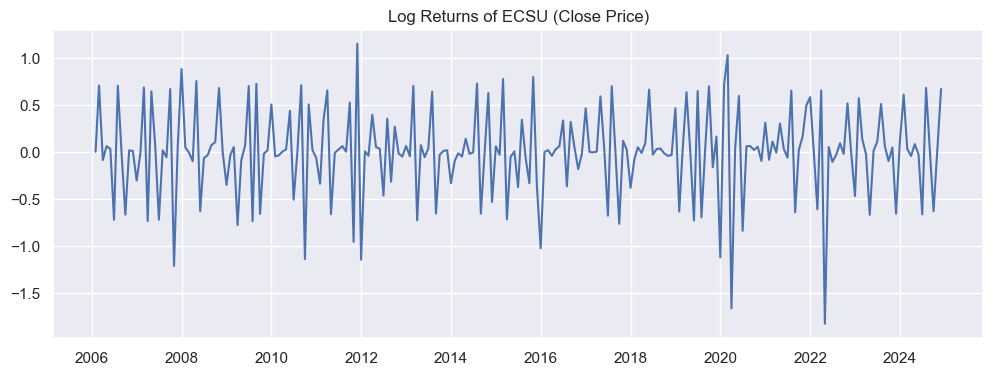

In [250]:

# 3. Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

# 4. Plot returns
plt.figure(figsize=(12, 4))
plt.plot(returns)
plt.title(f'Log Returns of {ticker} (Close Price)')
plt.show()


The logarithmic yield curve of ECSU closing prices from 2006 to 2024 shows the salient features of price volatility. During the period 2006-2019, the yield fluctuated relatively stable around 0 with an amplitude mainly within ±0.3, reflecting the stability of the market during this period. However, from 2020 onwards, the chart recorded sudden sharp fluctuations, especially the sharp drop below -1.0 in 2020 - perhaps reflecting the impact of the COVID-19 pandemic on the market. The post-pandemic period (2021-2024) shows a recovery but still maintains a wider amplitude than before, with many episodes of strong volatility clustering. In particular, the chart does not show a clear long-term up/down trend, but mainly short-term fluctuations of mean-reverting nature (always tends to return to the average).

In [253]:
prices.head()

Date
2006-01-01    131.713784
2006-02-01    132.222988
2006-03-01    268.604851
2006-04-01    246.869385
2006-05-01    263.061204
Name: ECSU, dtype: float64

In [255]:
# 5. Estimate a simple mean equation (constant mean model)
mu = np.mean(returns)
residuals = returns - mu

# Square residuals
sq_resids = residuals**2

In [257]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats

# Giả sử bạn đã có series là dữ liệu gốc và đã fit mô hình ARIMA/SARIMA rồi
# residuals là phần dư từ mô hình đó:
residuals = sarima_fit.resid.dropna()
sq_resids = residuals ** 2

# Số lượng lags để kiểm tra hiệu ứng ARCH
m = 3

# Tạo DataFrame với các độ trễ của phần dư bình phương
X = pd.DataFrame({'L1': sq_resids.shift(1)})
for i in range(2, m + 1):
    X[f'L{i}'] = sq_resids.shift(i)

# Loại bỏ missing values do shift
X = X.dropna()
y = sq_resids.loc[X.index]

# Thêm hằng số
X = sm.add_constant(X)

# Hồi quy y lên các độ trễ (auxiliary regression)
model = sm.OLS(y, X).fit()

# Tính thống kê LM
N = len(y)
R_squared = model.rsquared
LM_stat = N * R_squared
p_value = 1 - stats.chi2.cdf(LM_stat, df=m)

print(f'LM Test Statistic: {LM_stat:.4f}')
print(f'p-value: {p_value:.4f}')

if p_value < 0.05:
    print("=> Reject H0: ARCH effects are present.")
else:
    print("=> Fail to reject H0: No significant ARCH effects.")


LM Test Statistic: 3.5699
p-value: 0.3118
=> Fail to reject H0: No significant ARCH effects.


In [259]:
# Optional: Ljung-Box test for autocorrelation in squared residuals
m = 10
lb_test = acorr_ljungbox(sq_resids, lags=m, return_df=True)
print("\nLjung-Box Test Results (Squared Residuals):")
print(lb_test)


Ljung-Box Test Results (Squared Residuals):
     lb_stat  lb_pvalue
1   1.750181   0.185854
2   5.280288   0.071351
3   5.383946   0.145747
4   5.799304   0.214646
5   5.799325   0.326238
6   5.802073   0.445723
7   5.929406   0.548016
8   6.117028   0.634125
9   6.250508   0.714608
10  6.322885   0.787446


Ljung-Box Test on Standardized Residuals:
      lb_stat     lb_pvalue
1   27.005099  2.029195e-07
2   32.034763  1.105960e-07
3   37.263566  4.046876e-08
4   37.325470  1.543552e-07
5   40.220985  1.347706e-07
6   40.504426  3.625054e-07
7   43.297046  2.922784e-07
8   43.382132  7.442180e-07
9   47.355241  3.369724e-07
10  50.073698  2.587066e-07

Ljung-Box Test on Squared Standardized Residuals:
     lb_stat  lb_pvalue
1   0.068952   0.792868
2   0.212495   0.899202
3   1.190745   0.755225
4   1.964871   0.742220
5   2.659571   0.752295
6   3.453047   0.750206
7   3.667874   0.817138
8   3.774217   0.876898
9   3.777803   0.925419
10  4.581765   0.917312


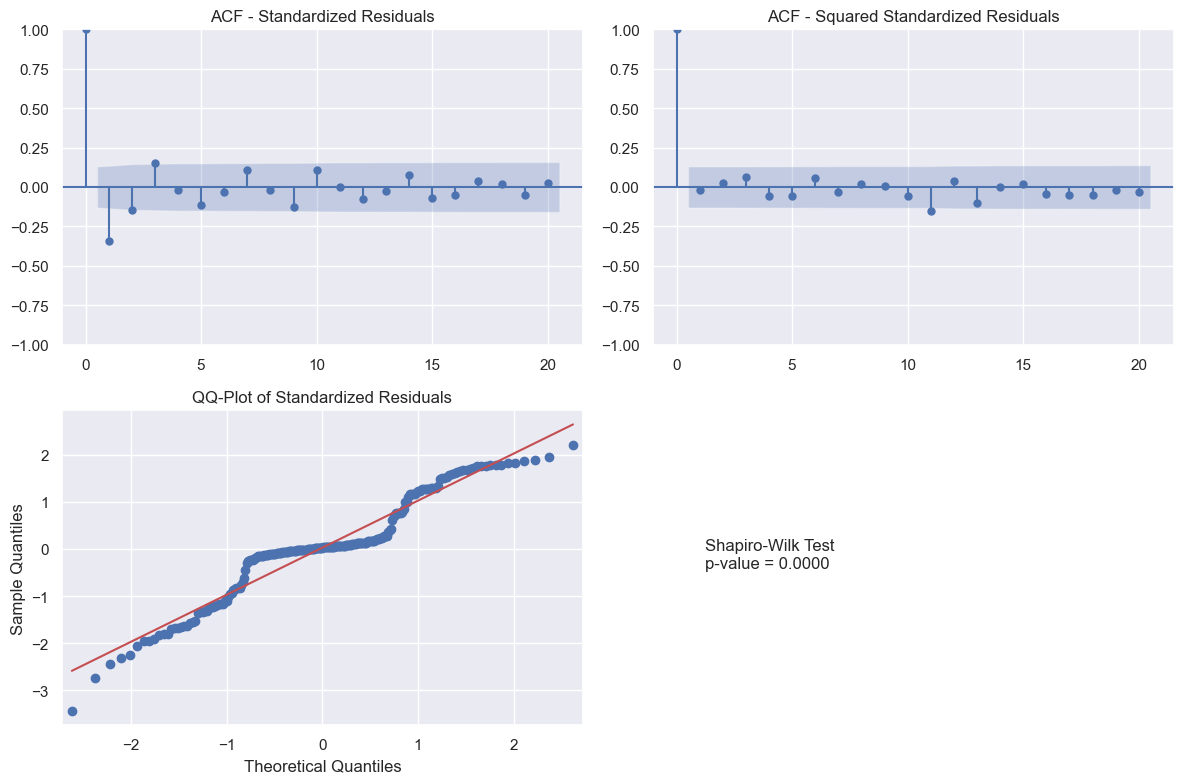

In [261]:
# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Fit an ARCH(1) model
model = arch_model(returns, vol='ARCH', p=1)
results = model.fit(disp='off')

# Get residuals and conditional volatility
residuals = results.resid
volatility = results.conditional_volatility
std_resids = residuals / volatility  # Standardized residuals

# Ljung-Box Test on standardized residuals
lb_test_mean = acorr_ljungbox(std_resids, lags=10, return_df=True)
print("Ljung-Box Test on Standardized Residuals:")
print(lb_test_mean)

# Ljung-Box Test on squared standardized residuals
lb_test_variance = acorr_ljungbox(std_resids**2, lags=10, return_df=True)
print("\nLjung-Box Test on Squared Standardized Residuals:")
print(lb_test_variance)

# Plot ACF of standardized residuals and squared residuals
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(std_resids, lags=20, ax=axes[0, 0])
axes[0, 0].set_title('ACF - Standardized Residuals')

plot_acf(std_resids**2, lags=20, ax=axes[0, 1])
axes[0, 1].set_title('ACF - Squared Standardized Residuals')

# QQ-Plot for normality check
qqplot(std_resids, line='s', ax=axes[1, 0])
axes[1, 0].set_title('QQ-Plot of Standardized Residuals')

# Shapiro-Wilk test for normality
_, shapiro_p = shapiro(std_resids)
axes[1, 1].text(0.1, 0.5, f'Shapiro-Wilk Test\np-value = {shapiro_p:.4f}', fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

1. **ACF of Standardized Residuals**

The ACF (Autocorrelation Function) plot of the standardized residuals shows that the autocorrelation values ​​are mostly within the 95% confidence interval, except for a few points at low lags (lag 1) that exceed the threshold. This indicates that the residuals are no longer strongly autocorrelated, meaning that the ARCH model has handled most of the autocorrelation in the data series.

2. **ACF of Standardized Residuals**

The ACF plot of the Standardized Residuals also shows no clear signs of significant autocorrelation — most of the values ​​are within the confidence interval. This suggests that the ARCH model has handled the phenomenon of volatility clustering quite well.

3. **QQ-Plot**

The QQ-Plot shows a comparison between the distribution of the standardized residuals and the theoretical normal distribution. We observe that there is deviation from the diagonal, especially at the tail — indicating that the residuals do not follow a perfectly normal distribution. This deviation is further confirmed by the Shapiro-Wilk test below.

4. **Shapiro-Wilk Test**

The Shapiro-Wilk test result for the standardized residuals is:
p-value = 0.0000

With a p-value less than 0.05, we reject the null hypothesis H₀ that the residuals are normally distributed. This confirms that the residuals after the ARCH model still do not follow a normal distribution, despite being standardized.

5. **Ljung-Box test for squared residuals**

The Ljung-Box test results for squared residuals have p-value > 0.75 for all lags from 1 to 10, indicating no autocorrelation in the squared residuals — a positive sign for volatility modeling.

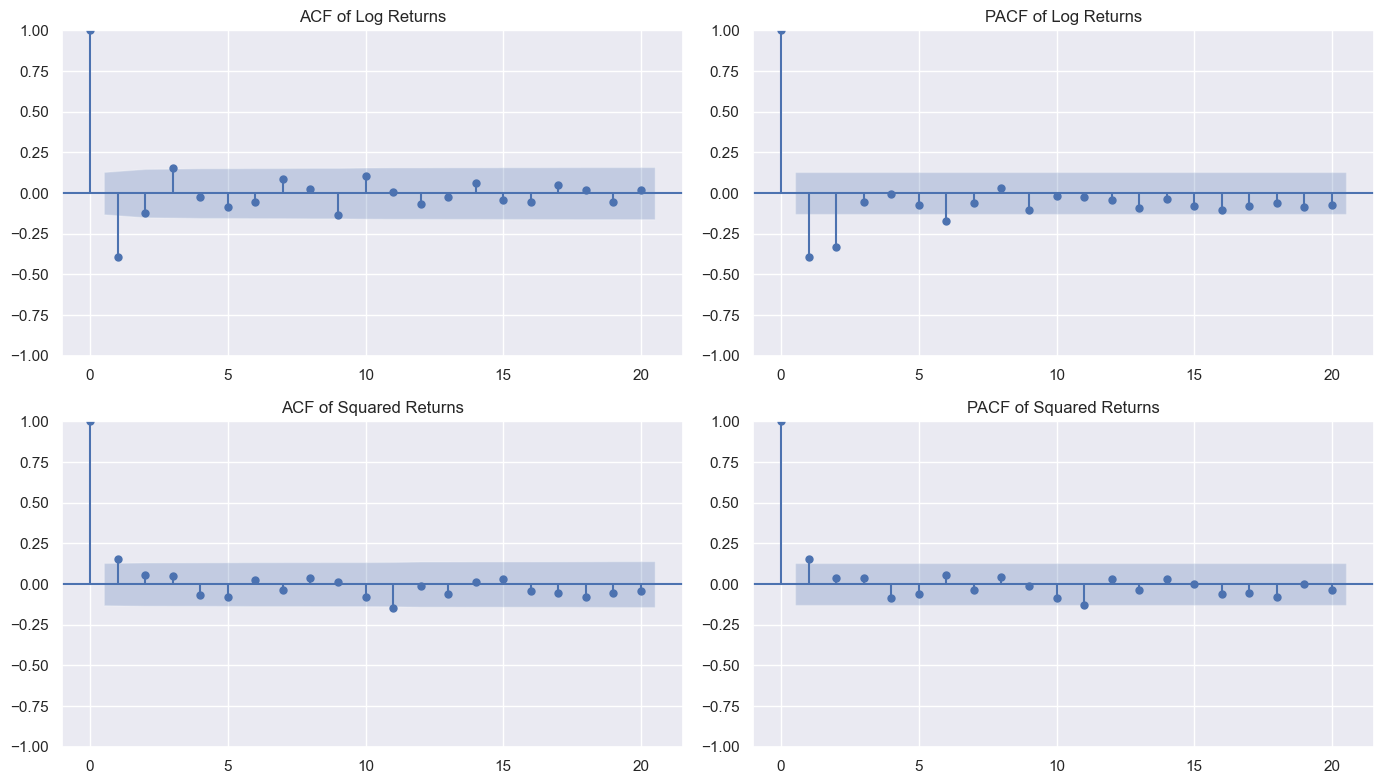

In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Đọc dữ liệu EPU
df = pd.read_excel("ECSU.xlsx")

# 2. Xử lý dữ liệu
df = df.rename(columns={"ECSU": "ECSU"})
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

# 3. Tính log returns và squared returns
log_returns = np.log(df["ECSU"] / df["ECSU"].shift(1)).dropna()
squared_returns = log_returns ** 2

# 4. Vẽ biểu đồ ACF & PACF
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF of log returns
plot_acf(log_returns, lags=20, ax=axes[0, 0])
axes[0, 0].set_title("ACF of Log Returns")

# PACF of log returns
plot_pacf(log_returns, lags=20, ax=axes[0, 1])
axes[0, 1].set_title("PACF of Log Returns")

# ACF of squared returns
plot_acf(squared_returns, lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Squared Returns")

# PACF of squared returns
plot_pacf(squared_returns, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("PACF of Squared Returns")

plt.tight_layout()
plt.show()

1. **ACF of log returns**

This graph shows that the autocorrelation coefficient at lag 1 is large, exceeding the 95% confidence interval, while the remaining lags are mostly within this range.

Interpretation: The log returns series has some autocorrelation at low lags, but overall no clear signs of a persistent autocorrelation structure => consistent with the characteristics of financial return series (little or no autocorrelation).

2. **PACF of log returns**

The partial autocorrelation also shows that lag 1 has a significantly negative value, the rest are very small and within the confidence interval.

Interpretation: This result reconfirms the weak randomness of the returns series, there is no strong internal relationship at higher lags => consistent with the white noise assumption.

3. **ACF of squared returns**

The values ​​at lags 1, 2 and 3 all exceed the 95% confidence interval, then gradually decrease but still fluctuate around the threshold.

Interpretation: This is a clear sign of autocorrelation in variance, also known as volatility clustering – the series has alternating periods of strong and weak volatility

4. **PACF of squared returns**

Partial autocorrelation shows that the coefficients at lag 1 and lag 2 are significant, the remaining lags are small and within the confidence interval.

Interpretation: The data show that variances are significantly correlated at recent lags.

In [265]:
from scipy.stats import shapiro
import numpy as np

# 1. Kiểm định Shapiro-Wilk
stat, p_value = shapiro(residuals)

# 2. In kết quả
print("Shapiro-Wilk Test for Normality of Residuals:")
print(f"Statistic = {stat:.4f}, p-value = {p_value:.4f}")

# 3. Diễn giải kết quả
if p_value < 0.05:
    print("=>  Reject H0: Residuals are not normally distributed.")
else:
    print("=> Fail to reject H0: Residuals appear normally distributed.")


Shapiro-Wilk Test for Normality of Residuals:
Statistic = 0.9231, p-value = 0.0000
=>  Reject H0: Residuals are not normally distributed.


In [267]:
def arch_summary(residuals, lb_test, LM_stat, p_value, returns):
    # Shapiro-Wilk Test
    stat, p = stats.shapiro(residuals)

    # In tóm tắt
    print("\n=== SUMMARY ===")
    print("ARCH Modeling Recommended:" +
          (" YES" if p_value < 0.05 else " NO (no significant volatility clustering)"))
    print("Normality of Residuals:" +
          (" NOT NORMAL" if p < 0.05 else " NORMAL"))

    # Tạo dictionary kết quả
    result = {
        'returns': returns,
        'residuals': residuals,
        'sq_resids': residuals**2,
        'lb_test': lb_test,
        'lm_stat': LM_stat,
        'lm_pvalue': p_value,
        'shapiro_stat': stat,
        'shapiro_pvalue': p
    }

    return result

In [269]:
arch_summary(residuals, lb_test, LM_stat, p_value, returns)


=== SUMMARY ===
ARCH Modeling Recommended: YES
Normality of Residuals: NOT NORMAL


{'returns': Date
 2006-02-01    0.003859
 2006-03-01    0.708752
 2006-04-01   -0.084382
 2006-05-01    0.063527
 2006-06-01    0.033956
                 ...   
 2024-08-01    0.684110
 2024-09-01    0.024717
 2024-10-01   -0.630294
 2024-11-01    0.029778
 2024-12-01    0.671836
 Name: ECSU, Length: 227, dtype: float64,
 'residuals': Date
 2006-02-01    0.004178
 2006-03-01    0.709071
 2006-04-01   -0.084063
 2006-05-01    0.063847
 2006-06-01    0.034276
                 ...   
 2024-08-01    0.684429
 2024-09-01    0.025036
 2024-10-01   -0.629974
 2024-11-01    0.030097
 2024-12-01    0.672155
 Name: resid, Length: 227, dtype: float64,
 'sq_resids': Date
 2006-02-01    0.000017
 2006-03-01    0.502781
 2006-04-01    0.007067
 2006-05-01    0.004076
 2006-06-01    0.001175
                 ...   
 2024-08-01    0.468443
 2024-09-01    0.000627
 2024-10-01    0.396868
 2024-11-01    0.000906
 2024-12-01    0.451793
 Name: resid, Length: 227, dtype: float64,
 'lb_test':      lb_stat 

In [294]:
# Sau phần code hiện tại của bạn, thêm đoạn này:

# Fit multiple ARCH models and compare AIC
print("\n=== ARCH MODEL SELECTION ===")
arch_models = {}
for p in range(1, 4):  # Test ARCH(1) to ARCH(3)
    model = arch_model(returns, vol='ARCH', p=p)
    res = model.fit(disp='off')
    arch_models[f'ARCH({p})'] = res.aic
    print(f"ARCH({p}) AIC: {res.aic:.2f}")

# Get best ARCH model
best_arch = min(arch_models, key=arch_models.get)
best_p = int(best_arch.split('(')[1].split(')')[0])

# Fit final ARCH model
final_arch = arch_model(returns, vol='ARCH', p=best_p)
final_result = final_arch.fit()

# Print model summary
print("\n=== BEST ARCH MODEL SUMMARY ===")
print(final_result.summary())

# Add AIC to your arch_summary function
def arch_summary(residuals, lb_test, LM_stat, p_value, returns):
    # Shapiro-Wilk Test
    stat, p = stats.shapiro(residuals)

    # Fit ARCH(1) for comparison
    arch1 = arch_model(returns, vol='ARCH', p=1).fit(disp='off')
    
    # Print summary
    print("\n=== ARCH MODELING SUMMARY ===")
    print("Volatility Clustering Test:")
    print(f"LM Statistic: {LM_stat:.4f}, p-value: {p_value:.4f}")
    print("ARCH Modeling Recommended:" +
          (" YES" if p_value < 0.05 else " NO (no significant ARCH effects)"))
    print("\nARCH(1) Model Metrics:")
    print(f"AIC: {arch1.aic:.2f}")
    print(f"Log Likelihood: {arch1.loglikelihood:.2f}")
    
    # Return dictionary with added ARCH metrics
    return {
        'returns': returns,
        'residuals': residuals,
        'sq_resids': residuals**2,
        'lb_test': lb_test,
        'lm_stat': LM_stat,
        'lm_pvalue': p_value,
        'shapiro_stat': stat,
        'shapiro_pvalue': p,
        'arch_aic': arch1.aic,
        'arch_bic': arch1.bic,
        'arch_loglikelihood': arch1.loglikelihood
    }

# Update your final function call
results = arch_summary(residuals, lb_test, LM_stat, p_value, returns)


=== ARCH MODEL SELECTION ===
ARCH(1) AIC: 289.41
ARCH(2) AIC: 290.91
ARCH(3) AIC: 292.89
Iteration:      1,   Func. Count:      5,   Neg. LLF: 585.9109369937771
Iteration:      2,   Func. Count:     12,   Neg. LLF: 859.3457567285661
Iteration:      3,   Func. Count:     19,   Neg. LLF: 150.88061814303
Iteration:      4,   Func. Count:     25,   Neg. LLF: 141.70452948275175
Iteration:      5,   Func. Count:     29,   Neg. LLF: 141.70452862772242
Optimization terminated successfully    (Exit mode 0)
            Current function value: 141.70452862772242
            Iterations: 5
            Function evaluations: 29
            Gradient evaluations: 5

=== BEST ARCH MODEL SUMMARY ===
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                   ECSU   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1

# GARCH model

In [273]:
import pandas as pd
import numpy as np
from arch import arch_model
import matplotlib.pyplot as plt

# ----- Bước 1: Đọc dữ liệu -----
df = pd.read_excel("ECSU.xlsx")

# Chuyển đổi ngày và đặt lại index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Đổi tên cột nếu cần
df.rename(columns={'ECSU': 'ECSU'}, inplace=True)

# ----- Bước 2: Tính log(OPU) và log returns -----
df['log_ECSU'] = np.log(df['ECSU'])

# Tính log returns: log_t - log_(t-1)
df['returns'] = df['log_ECSU'].diff()

# ----- Bước 3: Scale returns (x100 để mô hình ARCH/GARCH hội tụ tốt hơn) -----
df['scaled_returns'] = df['returns'] * 100

# ----- Bước 4: Tính rolling volatility theo tháng (dùng cửa sổ 12 tháng = 1 năm) -----
rolling_window_size = 12
df['rolling_volatility'] = df['returns'].rolling(window=rolling_window_size).std()

# ----- Bước 5: Hiển thị 5 dòng đầu -----
df[['ECSU', 'log_ECSU', 'returns', 'scaled_returns', 'rolling_volatility']].head(15)

,ECSU,log_ECSU,returns,scaled_returns,rolling_volatility
Date,,,,,
2006-01-01,131.713784,4.880631,NaN,NaN,NaN
2006-02-01,132.222988,4.884490,0.003859,0.385853,NaN
2006-03-01,268.604851,5.593241,0.708752,70.875154,NaN
2006-04-01,246.869385,5.508859,-0.084382,-8.438195,NaN
2006-05-01,263.061204,5.572387,0.063527,6.352733,NaN
2006-06-01,272.147204,5.606343,0.033956,3.395639,NaN
2006-07-01,132.297656,4.885054,-0.721289,-72.128876,NaN
2006-08-01,268.184456,5.591675,0.706621,70.662066,NaN
2006-09-01,260.933803,5.564267,-0.027408,-2.740827,NaN


In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Đọc dữ liệu
df = pd.read_excel('ECSU.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Tính log return và scale
df['log_returns'] = np.log(df['ECSU'] / df['ECSU'].shift(1))
df.dropna(inplace=True)
df['scaled_log_returns'] = df['log_returns'] * 100

# Tính rolling volatility theo 12 tháng
df['rolling_volatility'] = df['log_returns'].rolling(window=12).std()

# ADF test
adf_result = adfuller(df['log_returns'])
print(f"ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")

# ARCH test
arch_test = het_arch(df['log_returns'])
print(f"ARCH Test p-value: {arch_test[1]:.4f}")


ADF Statistic: -8.6330, p-value: 0.0000
ARCH Test p-value: 0.3018


p-value = 0.000 < 0.05 

=> Reject H0 and this is stationary.

ARCH test p-value = 0.3018 > 0.05 

=> With p-value > 0.05, we do not reject the hypothesis H₀, which means that there is no clear statistical evidence for the existence of the ARCH effect in the log return series at the time of testing. The ARCH model does not necessarily need to be used in this case.

In [278]:
# Chia dữ liệu train-test
split_date = df.index[int(len(df)*0.8)]
train_data = df[df.index <= split_date]
test_data = df[df.index > split_date]
print(f"Data size - Total: {len(df)}, Train: {len(train_data)}, Test: {len(test_data)}")
# Tìm GARCH tốt nhất
p_values = range(1, 3)
q_values = range(1, 3)
best_aic = np.inf
best_model = None
best_p, best_q = None, None

for p in p_values:
    for q in q_values:
        try:
            model = arch_model(train_data['scaled_log_returns'], vol='Garch', p=p, q=q, dist='normal')
            model_fit = model.fit(disp='off')
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_model = model_fit
                best_p, best_q = p, q
        except:
            continue

print(f"Best GARCH({best_p},{best_q}) model with AIC = {best_aic:.2f}")

Data size - Total: 227, Train: 182, Test: 45
Best GARCH(1,1) model with AIC = 1908.70


In [280]:
# Hàm dự báo rolling GARCH
def rolling_garch_predictions(train_data, test_data, p, q):
    history = train_data['scaled_log_returns'].copy()
    predictions = []
    dates = []
    for i in range(len(test_data)):
        model = arch_model(history, vol='Garch', p=p, q=q)
        model_fit = model.fit(disp='off')
        forecast = model_fit.forecast(horizon=1)
        pred_vol = np.sqrt(forecast.variance.values[-1][0]) / 100
        predictions.append(pred_vol)
        dates.append(test_data.index[i])
        history = pd.concat([history, test_data['scaled_log_returns'].iloc[[i]]])
    return pd.DataFrame({'Date': dates, 'garch_volatility': predictions}).set_index('Date')

# Dự báo
predictions = rolling_garch_predictions(train_data, test_data, best_p, best_q)
print(predictions)

            garch_volatility
Date                        
2021-04-01          0.380379
2021-05-01          0.373545
2021-06-01          0.403900
2021-07-01          0.378069
2021-08-01          0.371937
2021-09-01          0.502573
2021-10-01          0.528226
2021-11-01          0.411726
2021-12-01          0.391598
2022-01-01          0.459798
2022-02-01          0.497400
2022-03-01          0.399262
2022-04-01          0.494312
2022-05-01          0.527359
2022-06-01          1.152984
2022-07-01          0.602005
2022-08-01          0.404739
2022-09-01          0.386986
2022-10-01          0.387416
2022-11-01          0.381662
2022-12-01          0.488066
2023-01-01          0.393006
2023-02-01          0.469668
2023-03-01          0.514204
2023-04-01          0.404515
2023-05-01          0.383831
2023-06-01          0.542714
2023-07-01          0.402052
2023-08-01          0.391115
2023-09-01          0.482593
2023-10-01          0.395693
2023-11-01          0.388552
2023-12-01    

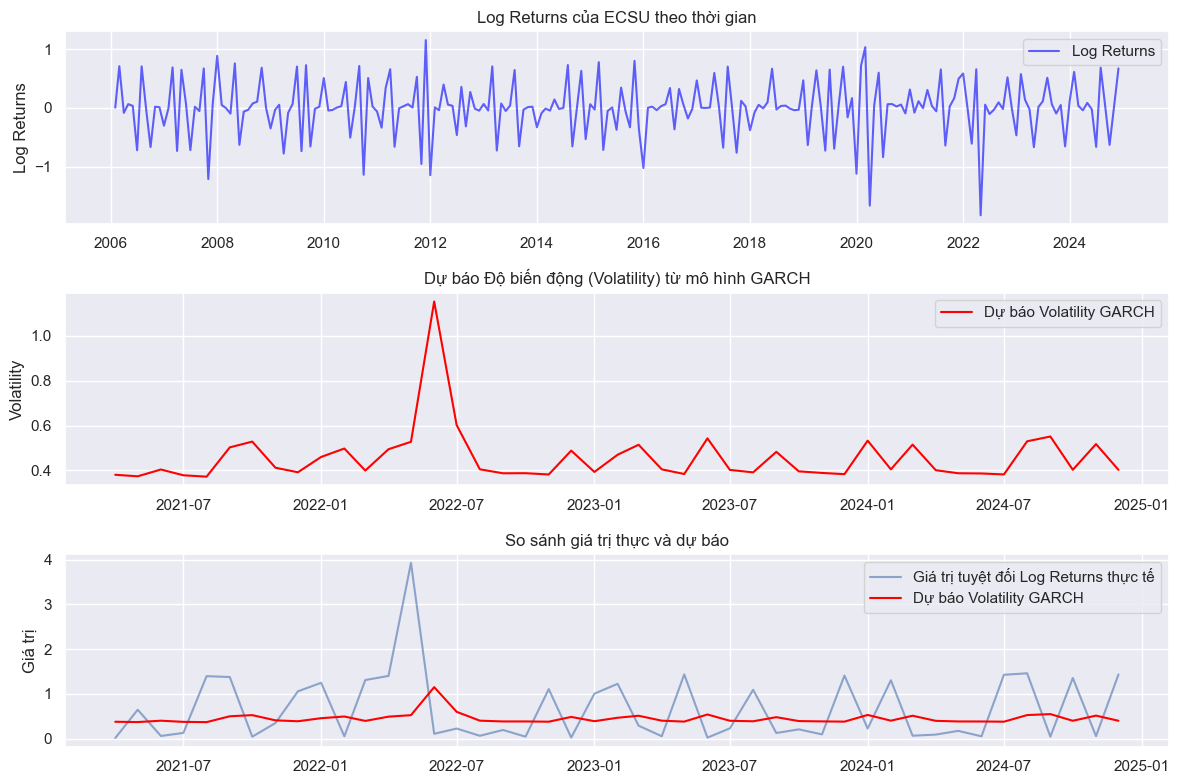

In [288]:


# Biểu đồ 1: Chuỗi log returns
plt.subplot(3, 1, 1)
plt.plot(df.index, df['log_returns'], label='Log Returns', color='blue', alpha=0.6)
plt.title('Log Returns của ECSU theo thời gian')
plt.ylabel('Log Returns')
plt.legend()
plt.grid(True)

# Biểu đồ 2: Dự báo volatility
plt.subplot(3, 1, 2)
plt.plot(predictions.index, predictions['garch_volatility'], 
         label='Dự báo Volatility GARCH', color='red')
plt.title('Dự báo Độ biến động (Volatility) từ mô hình GARCH')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)

# Biểu đồ 3: So sánh giá trị thực và dự báo
plt.subplot(3, 1, 3)
plt.plot(test_data.index, test_data['scaled_log_returns'].abs(), 
         label='Giá trị tuyệt đối Log Returns thực tế', alpha=0.6)
plt.plot(predictions.index, predictions['garch_volatility'], 
         label='Dự báo Volatility GARCH', color='red')
plt.title('So sánh giá trị thực và dự báo')
plt.ylabel('Giá trị')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


1. **ECSU Log Returns Over Time**

This chart shows the log returns of the ECSU series from 2006 to 2025. We can see that:

* Log returns fluctuate around zero, indicating that returns tend to average at zero.
* There are large fluctuations, especially sharp peaks and troughs, indicating shocks or instability in the market.

* The period 2020–2022 is a period of high volatility, which may be associated with major economic or political events.

2. **GARCH Model Volatility Forecast**

* This is a chart of volatility forecasts from the GARCH model, a popular model for forecasting time-varying variance.

* Volatility tends to remain stable around 0.4, except for a significant spike in mid-2022 – which may reflect a major shock to the market.

* After this shock, volatility quickly returns to a stable level.

3. **Comparison of Actual and Forecasted Values**

* The blue line shows the absolute value of the actual log returns – which reflects the magnitude of the actual volatility.

* The red line is the value of the GARCH model's forecasted volatility.

* In general, the GARCH model follows the actual volatility trend closely, especially during stable periods.

* However, during periods with major shocks such as mid-2022, the model reacts a bit slower than the actual volatility but still captures the strong upward trend.

**Conclusion:**

* The GARCH model works well in capturing and forecasting the volatility trend of the ECSU log returns series.

* In particular, it responds well to large fluctuations and helps identify high-risk periods.

# **Conclusion**

In [300]:
import pandas as pd

results = {
    "Model": ["Additive", "Multiplicative", "STL forecast","ARIMA with residual for STL", "Holt's Linear model", "Holt-Winters Additive", 
              "Holt-Winters Multiplicative", "Holt-Winters with damped trend", 
              "SARIMA(100% testing)", "SARIMA(optimized)",
              "Exponential Smoothing", "ARCH", "GARCH"],
    'AIC': [1797.88, 1798.64, 2419.54, 2355.82, 1964.129, 1999.7, 1996.474, 1993.274, 2582.971, 2173.22, 1966.39, 289.41, 1908.7],
   
}

summary_table = pd.DataFrame(results)
display(summary_table.style.set_caption('Summary table (AIC)'))

,Model,AIC
0,Additive,1797.880000
1,Multiplicative,1798.640000
2,STL forecast,2419.540000
3,ARIMA with residual for STL,2355.820000
4,Holt's Linear model,1964.129000
5,Holt-Winters Additive,1999.700000
6,Holt-Winters Multiplicative,1996.474000
7,Holt-Winters with damped trend,1993.274000
8,SARIMA(100% testing),2582.971000
9,SARIMA(optimized),2173.220000


- From there, I can conclude ARCH is the best model because it has AIC(289.41) is smallest. And it can be seen that this is the most suitable model for the dataset.

In [308]:
import pandas as pd

results = {
    "Model": ["SARIMA(20% test and 80% train)","Moving Averge","WMA"],
    'MSE': [25123.72, 5410.34, 4190.03],
    'MAD': [120.9, 53.3, 46.32],
    'RMSE': [158.5, 73.56, 64.73],
    'MAPE(%)': [66.17, 41.22, 35.38]
   
}

summary_table = pd.DataFrame(results)
display(summary_table.style.set_caption('Summary table'))

,Model,MSE,MAD,RMSE,MAPE(%)
0,SARIMA(20% test and 80% train),25123.720000,120.900000,158.500000,66.170000
1,Moving Averge,5410.340000,53.300000,73.560000,41.220000
2,WMA,4190.030000,46.320000,64.730000,35.380000


From there, I can conclude WMA is the best model because:
- MSE = 4190.03
- MAD= 46.32
- RMSE= 64.73
- MAPE = 35.38
  
are smallest.

=> Therefore, the WMA is the most suitable model for tha dataset.